In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Configuration du style pour des graphiques plus professionnels

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

NBA_Analysis = "NBA_Analysis_Results"  # Nom du dossier de destination

# On crée le dossier s'il n'existe pas encore
if not os.path.exists(NBA_Analysis):
    os.makedirs(NBA_Analysis)
    print(f"📁 Dossier '{NBA_Analysis}' créé avec succès.")

### 1.1. Charger les deux fichiers


In [3]:
team_totals = pd.read_csv('Team Totals.csv', sep=';')
team_summaries = pd.read_csv('Team Summaries.csv', sep=';')

### 1.2. Afficher les colonnes pour vérification

In [4]:
print("Colonnes de Team Totals :")
print(team_totals.columns.tolist())
print("\nColonnes de Team Summaries :")
print(team_summaries.columns.tolist())

Colonnes de Team Totals :
['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp', 'fg', 'fga', 'fg_percent', 'x3p', 'x3pa', 'x3p_percent', 'x2p', 'x2pa', 'x2p_percent', 'ft', 'fta', 'ft_percent', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'Unnamed: 28', 'Unnamed: 29']

Colonnes de Team Summaries :
['season', 'lg', 'team', 'abbreviation', 'playoffs', 'age', 'w', 'l', 'pw', 'pl', 'mov', 'sos', 'srs', 'o_rtg', 'd_rtg', 'n_rtg', 'pace', 'f_tr', 'x3p_ar', 'ts_percent', 'e_fg_percent', 'tov_percent', 'orb_percent', 'ft_fga', 'opp_e_fg_percent', 'opp_tov_percent', 'drb_percent', 'opp_ft_fga', 'arena', 'attend', 'attend_g']


### 1.3. Sélectionner les colonnes à ajouter depuis Team Summaries

In [5]:
# On prend les colonnes qui permettent d'identifier une ligne unique (clé)
# et les colonnes d'intérêt
columns_to_add = ['season', 'lg', 'team', 'abbreviation', 'age', 'w', 'l']
# Vérifier que toutes les colonnes existent
available_columns = [col for col in columns_to_add if col in team_summaries.columns]
print(f"\nColonnes disponibles dans Team Summaries : {available_columns}")


Colonnes disponibles dans Team Summaries : ['season', 'lg', 'team', 'abbreviation', 'age', 'w', 'l']


### 1.4. Fusionner les deux dataframes

In [6]:
# On fusionne sur les colonnes identifiantes (season, lg, team)
merged_df = pd.merge(
    team_totals,
    team_summaries[available_columns],
    on=['season', 'lg', 'team'],
    how='left'
)

### 1.5. Réorganiser les colonnes pour placer age, w, l juste après g

In [7]:
# Récupérer toutes les colonnes
cols = merged_df.columns.tolist()

# Trouver l'index de la colonne 'g'
if 'g' in cols:
    g_index = cols.index('g')
    
    # Colonnes à déplacer (age, w, l)
    cols_to_move = ['age', 'w', 'l']
    
    # Supprimer ces colonnes de leur position actuelle
    for col in cols_to_move:
        if col in cols:
            cols.remove(col)
    
    # Insérer les colonnes juste après 'g'
    for i, col in enumerate(reversed(cols_to_move)):
        cols.insert(g_index + 1, col)
    
    # Réorganiser le dataframe
    merged_df = merged_df[cols]
if 'abbreviation_y' in merged_df.columns:
    merged_df = merged_df.drop(columns=['abbreviation_y'])
print("\nColonnes après fusion et réorganisation :")
print(merged_df.columns.tolist())


Colonnes après fusion et réorganisation :
['season', 'lg', 'team', 'abbreviation_x', 'playoffs', 'g', 'age', 'w', 'l', 'mp', 'fg', 'fga', 'fg_percent', 'x3p', 'x3pa', 'x3p_percent', 'x2p', 'x2pa', 'x2p_percent', 'ft', 'fta', 'ft_percent', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'Unnamed: 28', 'Unnamed: 29']


## creation d'un tableau des champions NBA et des conference depuis le début de la ligue

In [8]:

# Données des champions NBA (1947-2025)
data = {
    "season": [1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956,
               1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966,
               1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
               1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
               1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996,
               1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
               2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
               2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    "champion": [
        "Philadelphia Warriors", "Baltimore Bullets", "Minneapolis Lakers",
        "Minneapolis Lakers", "Rochester Royals", "Minneapolis Lakers",
        "Minneapolis Lakers", "Minneapolis Lakers", "Syracuse Nationals",
        "Philadelphia Warriors", "Boston Celtics", "St. Louis Hawks",
        "Boston Celtics", "Boston Celtics", "Boston Celtics", "Boston Celtics",
        "Boston Celtics", "Boston Celtics", "Boston Celtics", "Boston Celtics",
        "Philadelphia 76ers", "Boston Celtics", "Boston Celtics", "New York Knicks",
        "Milwaukee Bucks", "Los Angeles Lakers", "New York Knicks", "Boston Celtics",
        "Golden State Warriors", "Boston Celtics", "Portland Trail Blazers",
        "Washington Bullets", "Seattle SuperSonics", "Los Angeles Lakers",
        "Boston Celtics", "Los Angeles Lakers", "Philadelphia 76ers",
        "Boston Celtics", "Los Angeles Lakers", "Boston Celtics",
        "Los Angeles Lakers", "Los Angeles Lakers", "Detroit Pistons",
        "Detroit Pistons", "Chicago Bulls", "Chicago Bulls", "Chicago Bulls",
        "Houston Rockets", "Houston Rockets", "Chicago Bulls", "Chicago Bulls",
        "Chicago Bulls", "San Antonio Spurs", "Los Angeles Lakers",
        "Los Angeles Lakers", "Los Angeles Lakers", "San Antonio Spurs",
        "Detroit Pistons", "San Antonio Spurs", "Miami Heat", "San Antonio Spurs",
        "Boston Celtics", "Los Angeles Lakers", "Los Angeles Lakers",
        "Dallas Mavericks", "Miami Heat", "Miami Heat", "San Antonio Spurs",
        "Golden State Warriors", "Cleveland Cavaliers", "Golden State Warriors",
        "Golden State Warriors", "Toronto Raptors", "Los Angeles Lakers",
        "Milwaukee Bucks", "Golden State Warriors", "Denver Nuggets", "Boston Celtics"
    ],
    "runner_up": [
        "Chicago Stags", "Philadelphia Warriors", "Washington Capitols",
        "Syracuse Nationals", "New York Knicks", "New York Knicks", "New York Knicks",
        "Syracuse Nationals", "Fort Wayne Pistons", "Fort Wayne Pistons",
        "St. Louis Hawks", "Boston Celtics", "Minneapolis Lakers", "St. Louis Hawks",
        "St. Louis Hawks", "Los Angeles Lakers", "Los Angeles Lakers",
        "San Francisco Warriors", "Los Angeles Lakers", "Los Angeles Lakers",
        "San Francisco Warriors", "Los Angeles Lakers", "Los Angeles Lakers",
        "Los Angeles Lakers", "Baltimore Bullets", "New York Knicks",
        "Los Angeles Lakers", "Milwaukee Bucks", "Washington Bullets",
        "Phoenix Suns", "Philadelphia 76ers", "Seattle SuperSonics",
        "Washington Bullets", "Philadelphia 76ers", "Houston Rockets",
        "Philadelphia 76ers", "Los Angeles Lakers", "Los Angeles Lakers",
        "Boston Celtics", "Houston Rockets", "Boston Celtics", "Detroit Pistons",
        "Los Angeles Lakers", "Portland Trail Blazers", "Los Angeles Lakers",
        "Portland Trail Blazers", "Phoenix Suns", "New York Knicks", "Orlando Magic",
        "Seattle SuperSonics", "Utah Jazz", "Utah Jazz", "New York Knicks",
        "Indiana Pacers", "Philadelphia 76ers", "New Jersey Nets", "New Jersey Nets",
        "Los Angeles Lakers", "Detroit Pistons", "Dallas Mavericks",
        "Cleveland Cavaliers", "Los Angeles Lakers", "Orlando Magic", "Boston Celtics",
        "Miami Heat", "Oklahoma City Thunder", "San Antonio Spurs", "Miami Heat",
        "Cleveland Cavaliers", "Golden State Warriors", "Cleveland Cavaliers",
        "Cleveland Cavaliers", "Golden State Warriors", "Miami Heat", "Phoenix Suns",
        "Boston Celtics", "Miami Heat", "Dallas Mavericks"
    ],
    "result": [
        "4-1", "4-2", "4-2", "4-2", "4-3", "4-3", "4-1", "4-3", "4-3", "4-1",
        "4-3", "4-2", "4-0", "4-3", "4-1", "4-3", "4-2", "4-1", "4-1", "4-3",
        "4-2", "4-2", "4-3", "4-3", "4-0", "4-1", "4-1", "4-3", "4-0", "4-2",
        "4-2", "4-3", "4-1", "4-2", "4-2", "4-2", "4-0", "4-3", "4-2", "4-2",
        "4-2", "4-3", "4-0", "4-1", "4-1", "4-2", "4-2", "4-3", "4-0", "4-2",
        "4-2", "4-2", "4-1", "4-2", "4-1", "4-0", "4-2", "4-1", "4-3", "4-2",
        "4-0", "4-2", "4-1", "4-3", "4-2", "4-1", "4-3", "4-1", "4-2", "4-3",
        "4-1", "4-0", "4-2", "4-2", "4-2", "4-2", "4-1", "4-1"
    ]
}

# Créer le DataFrame
df_champions = pd.DataFrame(data)

# Afficher le tableau
print(df_champions)

# Sauvegarder en CSV (optionnel)
df_champions.to_csv("nba_champions.csv", index=False)

    season               champion              runner_up result
0     1947  Philadelphia Warriors          Chicago Stags    4-1
1     1948      Baltimore Bullets  Philadelphia Warriors    4-2
2     1949     Minneapolis Lakers    Washington Capitols    4-2
3     1950     Minneapolis Lakers     Syracuse Nationals    4-2
4     1951       Rochester Royals        New York Knicks    4-3
..     ...                    ...                    ...    ...
73    2020     Los Angeles Lakers             Miami Heat    4-2
74    2021        Milwaukee Bucks           Phoenix Suns    4-2
75    2022  Golden State Warriors         Boston Celtics    4-2
76    2023         Denver Nuggets             Miami Heat    4-1
77    2024         Boston Celtics       Dallas Mavericks    4-1

[78 rows x 4 columns]


In [9]:
import pandas as pd

nba_champions = pd.read_csv("nba_champions.csv", sep=',')
# Ajouter une colonne "is_champion" booléenne
print(nba_champions.head())
print(merged_df.head())
# Fusionner pour ajouter le nom du champion sur chaque ligne (left join)
team_champions = pd.merge(merged_df, nba_champions, on="season", how="left")

# Créer la colonne booléenne is_champion
team_champions["is_champion"] = team_champions["team"] == team_champions["champion"]

# Vérifier
print(team_champions[team_champions["is_champion"]][["season", "team", "champion"]].head(10))
print(team_champions.columns.tolist())



   season               champion              runner_up result
0    1947  Philadelphia Warriors          Chicago Stags    4-1
1    1948      Baltimore Bullets  Philadelphia Warriors    4-2
2    1949     Minneapolis Lakers    Washington Capitols    4-2
3    1950     Minneapolis Lakers     Syracuse Nationals    4-2
4    1951       Rochester Royals        New York Knicks    4-3
   season   lg               team abbreviation_x  playoffs     g   age     w  \
0    2026  NBA      Atlanta Hawks            ATL     False  61.0  25.0  30.0   
1    2026  NBA     Boston Celtics            BOS     False  59.0  26.8  39.0   
2    2026  NBA      Brooklyn Nets            BRK     False  59.0  23.5  15.0   
3    2026  NBA      Chicago Bulls            CHI     False  60.0  25.7  24.0   
4    2026  NBA  Charlotte Hornets            CHO     False  61.0  23.9  30.0   

      l       mp  ...     drb     trb     ast    stl    blk    tov      pf  \
0  31.0  14690.0  ...  1994.0  2631.0  1851.0  571.0  285.0  87

In [10]:
# Données des conférences NBA (1996-2025)
df_confer = {
    'ATL':'Est','BOS':'Est','BRK':'Est','NJN':'Est','CHA':'Est','CHH':'Est',
    'CHO':'Est','CHI':'Est','CLE':'Est','DET':'Est','IND':'Est','MIA':'Est',
    'MIL':'Est','NYK':'Est','ORL':'Est','PHI':'Est','TOR':'Est','WAS':'Est','WSB':'Est',
    'DAL':'Ouest','DEN':'Ouest','GSW':'Ouest','HOU':'Ouest','LAC':'Ouest','LAL':'Ouest',
    'MEM':'Ouest','VAN':'Ouest','MIN':'Ouest','NOP':'Ouest','NOH':'Ouest','NOK':'Ouest',
    'OKC':'Ouest','SEA':'Ouest','PHO':'Ouest','POR':'Ouest','SAC':'Ouest','SDC':'Ouest',
    'SAS':'Ouest','UTA':'Ouest','KCK':'Ouest',
}
team_complete = team_champions
# 4. Ajout de la conférence pour chaque équipe
# On utilise abbreviation_x comme référence pour créer la colonne 'confi'
team_complete['confi'] = team_complete['abbreviation_x'].map(df_confer)

# 5. Réorganisation des colonnes : placer 'confi' à côté de 'abbreviation_x'
# On récupère la liste des colonnes actuelles
cols = list(team_complete.columns)
# On trouve l'index de abbreviation_x
idx = cols.index('abbreviation_x')
# On retire 'confi' de sa position actuelle (la fin) et on l'insère après 'abbreviation_x'
cols.insert(idx + 1, cols.pop(cols.index('confi')))
team_complete = team_complete[cols]


### 1.6. Vérifier les premières lignes du résultat

In [11]:

print("\n=== APERÇU DU NOUVEAU TABLEAU ===\n")
print(team_complete.head(10))


=== APERÇU DU NOUVEAU TABLEAU ===

   season   lg                   team abbreviation_x  confi  playoffs     g  \
0    2026  NBA          Atlanta Hawks            ATL    Est     False  61.0   
1    2026  NBA         Boston Celtics            BOS    Est     False  59.0   
2    2026  NBA          Brooklyn Nets            BRK    Est     False  59.0   
3    2026  NBA          Chicago Bulls            CHI    Est     False  60.0   
4    2026  NBA      Charlotte Hornets            CHO    Est     False  61.0   
5    2026  NBA    Cleveland Cavaliers            CLE    Est     False  61.0   
6    2026  NBA       Dallas Mavericks            DAL  Ouest     False  59.0   
7    2026  NBA         Denver Nuggets            DEN  Ouest     False  60.0   
8    2026  NBA        Detroit Pistons            DET    Est     False  58.0   
9    2026  NBA  Golden State Warriors            GSW  Ouest     False  60.0   

    age     w     l  ...    blk    tov      pf     pts  Unnamed: 28  \
0  25.0  30.0  31.0  ..

### 1.7. Afficher les colonnes dans l'ordre final

In [12]:
print("\n=== ORDRE DES COLONNES FINAL ===\n")
for i, col in enumerate(team_complete.columns):
    print(f"{i+1:2d}. {col}")


=== ORDRE DES COLONNES FINAL ===

 1. season
 2. lg
 3. team
 4. abbreviation_x
 5. confi
 6. playoffs
 7. g
 8. age
 9. w
10. l
11. mp
12. fg
13. fga
14. fg_percent
15. x3p
16. x3pa
17. x3p_percent
18. x2p
19. x2pa
20. x2p_percent
21. ft
22. fta
23. ft_percent
24. orb
25. drb
26. trb
27. ast
28. stl
29. blk
30. tov
31. pf
32. pts
33. Unnamed: 28
34. Unnamed: 29
35. champion
36. runner_up
37. result
38. is_champion


### 1.9. Sauvegarder le nouveau fichier (optionnel)

In [13]:
team_complete.to_csv('Team_Complete.csv', index=False)
print("\n✅ Fichier 'Team_Complete.csv' sauvegardé avec succès !")


✅ Fichier 'Team_Complete.csv' sauvegardé avec succès !


# Analyse

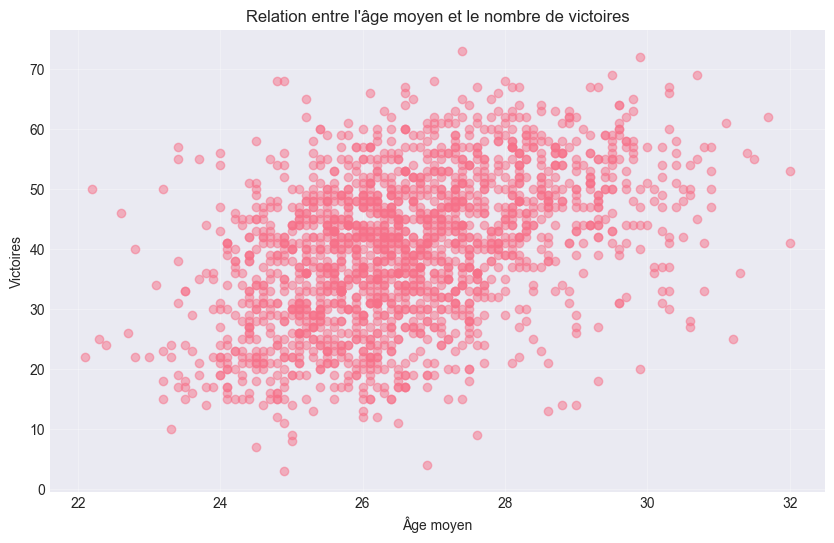

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(team_complete['age'], team_complete['w'], alpha=0.5)
plt.xlabel('Âge moyen')
plt.ylabel('Victoires')
plt.title('Relation entre l\'âge moyen et le nombre de victoires')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(NBA_Analysis, "team_age_vs_wins.png"), dpi=2160, bbox_inches='tight')
plt.show()

# 3. Nettoyer et préparer les données

Agréger les données par saison (moyenne sur toutes les équipes de la ligue)

Pour les tirs marqués, on prend la moyenne par match (pts / g) mais ici nous avons les totaux

On calcule les totaux de la ligue par saison

In [15]:
# 3. Nettoyer et préparer les données
# Filtrer uniquement la NBA (si vous voulez exclure l'ABA, commentez cette ligne)
team_complete = team_complete[team_complete['lg'] == 'NBA']

In [16]:
season_stats = team_complete.groupby('season').agg({
    'x2p': 'sum',      # Total des tirs à 2 points marqués
    'x3p': 'sum',      # Total des tirs à 3 points marqués
    'ft': 'sum',       # Total des lancers-francs marqués
    'pts': 'sum',      # Total des points
    'g': 'sum'         # Total des matchs
}).reset_index()

In [17]:
season_stats['x2p_per_game'] = (season_stats['x2p'] * 2) / season_stats['g']
season_stats['x3p_per_game'] = (season_stats['x3p'] * 3) / season_stats['g']
season_stats['ft_per_game'] = season_stats['ft'] / season_stats['g']
season_stats['total_points_per_game'] = season_stats['pts'] / season_stats['g']

In [18]:
# Trier par saison
season_stats = season_stats.sort_values('season')

# 4. Créer la figure avec 4 sous-graphiques

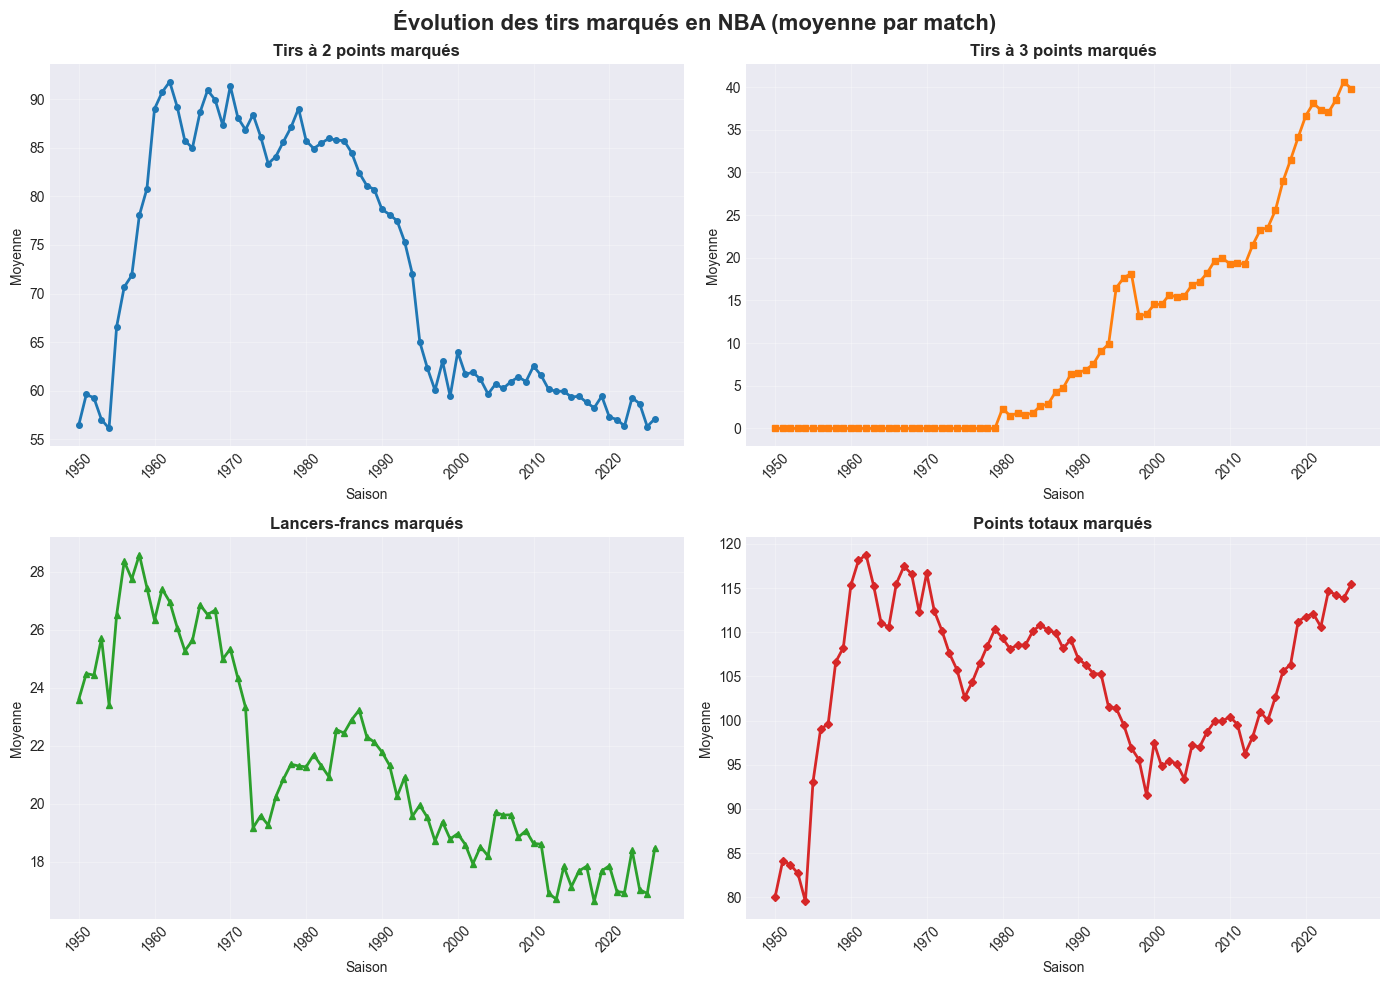

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Évolution des tirs marqués en NBA (moyenne par match)', fontsize=16, fontweight='bold')
# Graphique 1 : Tirs à 2 points
ax1 = axes[0, 0]
ax1.plot(season_stats['season'], season_stats['x2p_per_game'], 
         marker='o', linewidth=2, markersize=4, color='#1f77b4')
ax1.set_title('Tirs à 2 points marqués', fontsize=12, fontweight='bold')
ax1.set_xlabel('Saison')
ax1.set_ylabel('Moyenne')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Graphique 2 : Tirs à 3 points
ax2 = axes[0, 1]
ax2.plot(season_stats['season'], season_stats['x3p_per_game'], 
         marker='s', linewidth=2, markersize=4, color='#ff7f0e')
ax2.set_title('Tirs à 3 points marqués', fontsize=12, fontweight='bold')
ax2.set_xlabel('Saison')
ax2.set_ylabel('Moyenne')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Graphique 3 : Lancers-francs
ax3 = axes[1, 0]
ax3.plot(season_stats['season'], season_stats['ft_per_game'], 
         marker='^', linewidth=2, markersize=4, color='#2ca02c')
ax3.set_title('Lancers-francs marqués', fontsize=12, fontweight='bold')
ax3.set_xlabel('Saison')
ax3.set_ylabel('Moyenne')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Graphique 4 : Points totaux (pour comparaison)
ax4 = axes[1, 1]
ax4.plot(season_stats['season'], season_stats['total_points_per_game'], 
         marker='D', linewidth=2, markersize=4, color='#d62728')
ax4.set_title('Points totaux marqués', fontsize=12, fontweight='bold')
ax4.set_xlabel('Saison')
ax4.set_ylabel('Moyenne')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Ajuster la disposition
plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "season_stats.png"), dpi=2160, bbox_inches='tight')
plt.show()

# 5. Graphique combiné (les 4 courbes sur un seul graphique)

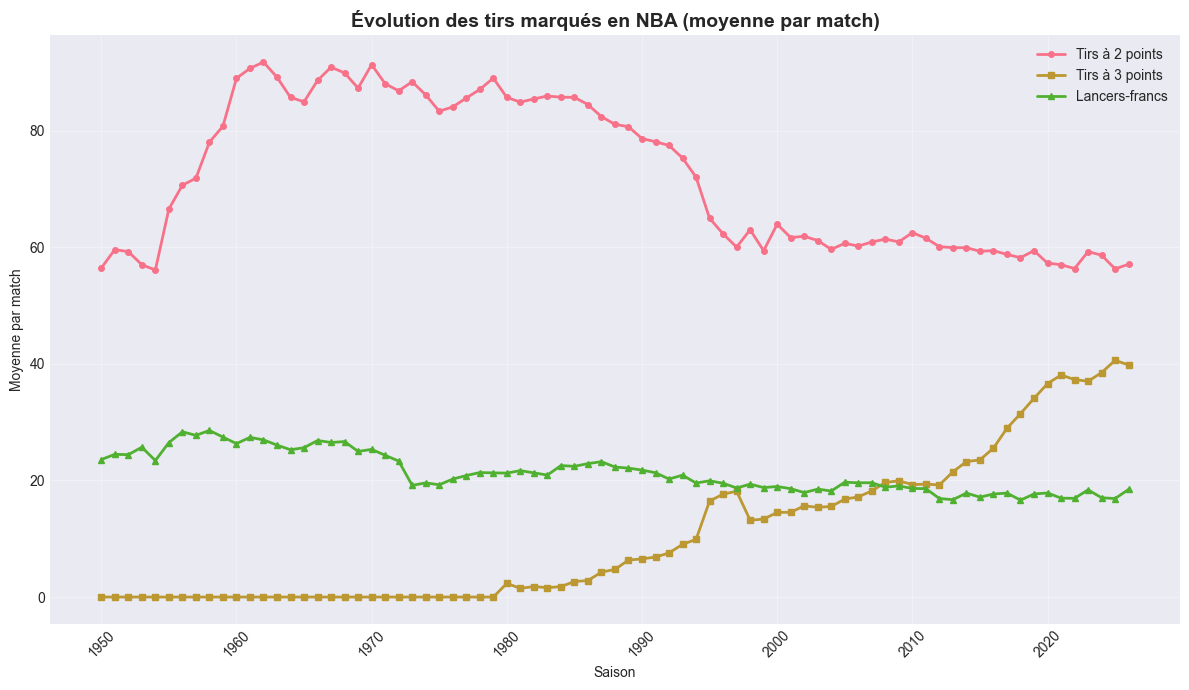

In [20]:

fig2, ax = plt.subplots(figsize=(12, 7))

ax.plot(season_stats['season'], season_stats['x2p_per_game'], 
        marker='o', linewidth=2, markersize=4, label='Tirs à 2 points')
ax.plot(season_stats['season'], season_stats['x3p_per_game'], 
        marker='s', linewidth=2, markersize=4, label='Tirs à 3 points')
ax.plot(season_stats['season'], season_stats['ft_per_game'], 
        marker='^', linewidth=2, markersize=4, label='Lancers-francs')

ax.set_title('Évolution des tirs marqués en NBA (moyenne par match)', fontsize=14, fontweight='bold')
ax.set_xlabel('Saison')
ax.set_ylabel('Moyenne par match')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "season_stats_combined.png"), dpi=1080, bbox_inches='tight')
plt.show()

# 6. Afficher les statistiques clés

In [21]:
print("\n=== STATISTIQUES CLÉS ===\n")

print("Saison avec le plus de tirs à 2 points marqués par match :")
max_2p = season_stats.loc[season_stats['x2p_per_game'].idxmax()]
print(f"  {int(max_2p['season'])} : {max_2p['x2p_per_game']:.1f} par match")

print("\nSaison avec le plus de tirs à 3 points marqués par match :")
max_3p = season_stats.loc[season_stats['x3p_per_game'].idxmax()]
print(f"  {int(max_3p['season'])} : {max_3p['x3p_per_game']:.1f} par match")

print("\nSaison avec le plus de lancers-francs marqués par match :")
max_ft = season_stats.loc[season_stats['ft_per_game'].idxmax()]
print(f"  {int(max_ft['season'])} : {max_ft['ft_per_game']:.1f} par match")


=== STATISTIQUES CLÉS ===

Saison avec le plus de tirs à 2 points marqués par match :
  1962 : 91.8 par match

Saison avec le plus de tirs à 3 points marqués par match :
  2025 : 40.6 par match

Saison avec le plus de lancers-francs marqués par match :
  1958 : 28.6 par match


# 7. Calcul des évolutions

In [22]:
print("\n=== ÉVOLUTIONS (entre la première et la dernière saison) ===\n")

first_season = season_stats.iloc[0]
last_season = season_stats.iloc[-2]

print(f"Période : {int(first_season['season'])} → {int(last_season['season'])}")
print(f"Tirs à 2 points : {first_season['x2p_per_game']:.1f} → {last_season['x2p_per_game']:.1f} "
      f"({(last_season['x2p_per_game'] - first_season['x2p_per_game']):+.1f})")
print(f"Tirs à 3 points : {first_season['x3p_per_game']:.1f} → {last_season['x3p_per_game']:.1f} "
      f"({(last_season['x3p_per_game'] - first_season['x3p_per_game']):+.1f})")
print(f"Lancers-francs : {first_season['ft_per_game']:.1f} → {last_season['ft_per_game']:.1f} "
      f"({(last_season['ft_per_game'] - first_season['ft_per_game']):+.1f})")


=== ÉVOLUTIONS (entre la première et la dernière saison) ===

Période : 1950 → 2025
Tirs à 2 points : 56.5 → 56.3 (-0.1)
Tirs à 3 points : 0.0 → 40.6 (+40.6)
Lancers-francs : 23.6 → 16.9 (-6.7)


# 8. Graphique avec zones pour visualiser les changements d'ère

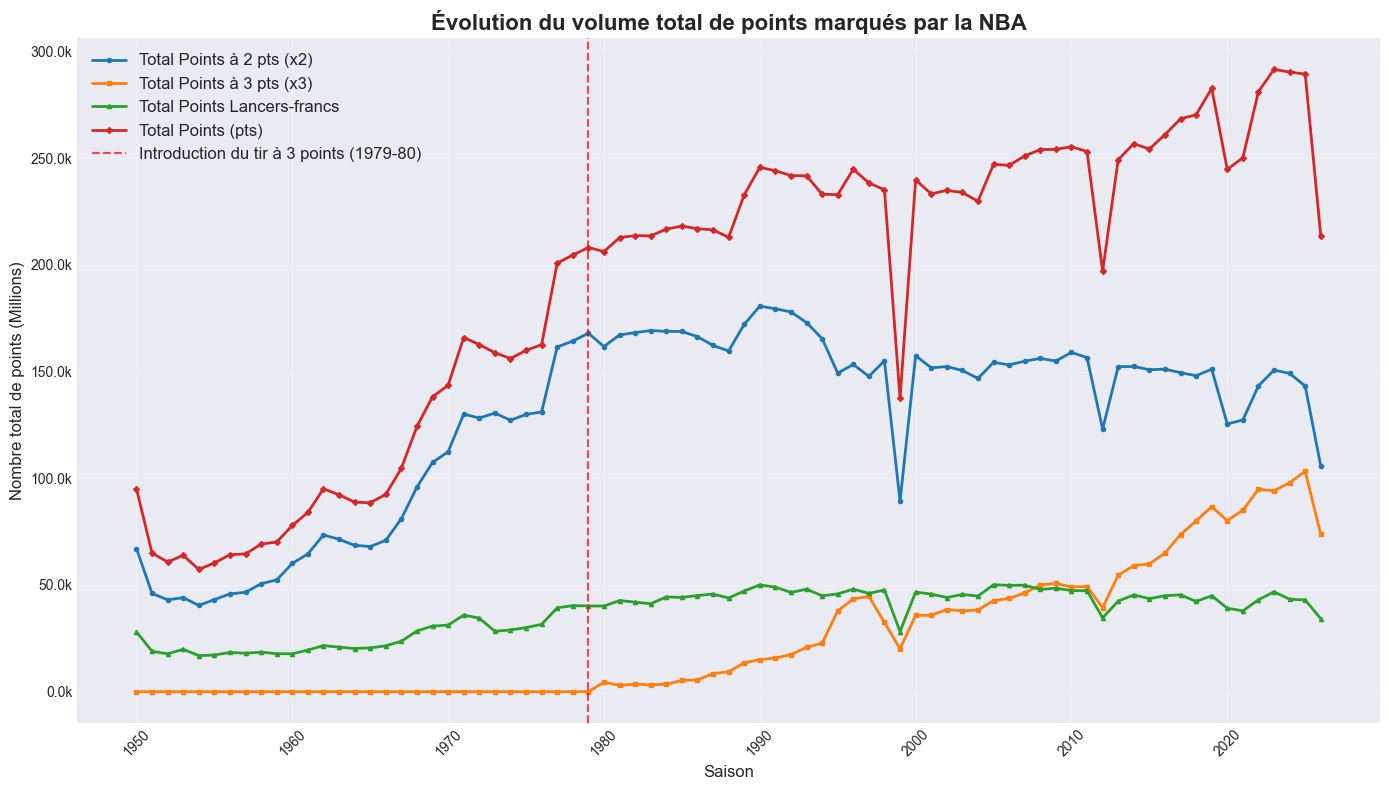

--- VOLUME TOTAL DE POINTS MARQUÉS DANS LA LIGUE ---
Saison 1950 :
  - Points à 2pts : 67,068
  - Points à 3pts : 0
  - Points LF    : 28,021
  - TOTAL        : 95,089

Saison 2025 :
  - Points à 2pts : 143,142
  - Points à 3pts : 103,242
  - Points LF    : 42,960
  - TOTAL        : 289,344


In [23]:


# 1. Calcul des points totaux cumulés par la ligue par saison
# On multiplie le nombre de tirs réussis par leur valeur respective
season_stats['total_pts_x2p'] = season_stats['x2p'] * 2
season_stats['total_pts_x3p'] = season_stats['x3p'] * 3
season_stats['total_pts_ft'] = season_stats['ft']    # 1 point par lancer-franc
season_stats['total_points_score'] = season_stats['pts']

# S'assurer que les données sont triées par année
season_stats = season_stats.sort_values('season')

# 2. Création du graphique d'évolution brute
plt.figure(figsize=(14, 8))

# On trace l'évolution de chaque catégorie
plt.plot(season_stats['season'], season_stats['total_pts_x2p'], 
         label='Total Points à 2 pts (x2)', color='#1f77b4', linewidth=2, marker='o', markersize=3)

plt.plot(season_stats['season'], season_stats['total_pts_x3p'], 
         label='Total Points à 3 pts (x3)', color='#ff7f0e', linewidth=2, marker='s', markersize=3)

plt.plot(season_stats['season'], season_stats['total_pts_ft'], 
         label='Total Points Lancers-francs', color='#2ca02c', linewidth=2, marker='^', markersize=3)
plt.plot(season_stats['season'], season_stats['total_points_score'], 
         label='Total Points (pts)', color='#d62728', linewidth=2, marker='D', markersize=3)

# Ajouter une ligne verticale pour l'introduction du tir à 3 points (1979-1980)
plt.axvline(x=1979, color='red', linestyle='--', alpha=0.7, label='Introduction du tir à 3 points (1979-80)')

# Configuration du graphique
plt.title('Évolution du volume total de points marqués par la NBA', fontsize=16, fontweight='bold')
plt.xlabel('Saison', fontsize=12)
plt.ylabel('Nombre total de points (Millions)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Formater l'axe Y pour une meilleure lecture si les chiffres sont très grands
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'{x*1e-3:.1f}k' # Affiche en milliers pour la lisibilité
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "total_points_evolution.png"), dpi=2160, bbox_inches='tight')
plt.show()

# 3. Affichage des chiffres bruts pour comparer les époques
first_year = season_stats.iloc[0]
last_year = season_stats.iloc[-2]

print(f"--- VOLUME TOTAL DE POINTS MARQUÉS DANS LA LIGUE ---")
print(f"Saison {int(first_year['season'])} :")
print(f"  - Points à 2pts : {int(first_year['total_pts_x2p']):,}")
print(f"  - Points à 3pts : {int(first_year['total_pts_x3p']):,}")
print(f"  - Points LF    : {int(first_year['total_pts_ft']):,}")
print(f"  - TOTAL        : {int(first_year['total_points_score']):,}")

print(f"\nSaison {int(last_year['season'])} :")
print(f"  - Points à 2pts : {int(last_year['total_pts_x2p']):,}")
print(f"  - Points à 3pts : {int(last_year['total_pts_x3p']):,}")
print(f"  - Points LF    : {int(last_year['total_pts_ft']):,}")
print(f"  - TOTAL        : {int(last_year['total_points_score']):,}")

# COMPARAISON ENTRE CONFERENCE

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_confer_96 = team_complete[team_complete['season'] >= 1996].copy()
df_confer_96['win_rate'] = df_confer_96['w'] / (df_confer_96['w'] + df_confer_96['l'])

BG_COLOR = '#0d1117'
CARD_COLOR = '#161b22'
GRID_COLOR = '#30363d'
CONF_COLORS = {'Est': '#1a6eb5', 'Ouest': '#c0392b'}


print("✅ Données chargées et préparées")
print(df_confer_96.head())


✅ Données chargées et préparées
   season   lg               team abbreviation_x confi  playoffs     g   age  \
0    2026  NBA      Atlanta Hawks            ATL   Est     False  61.0  25.0   
1    2026  NBA     Boston Celtics            BOS   Est     False  59.0  26.8   
2    2026  NBA      Brooklyn Nets            BRK   Est     False  59.0  23.5   
3    2026  NBA      Chicago Bulls            CHI   Est     False  60.0  25.7   
4    2026  NBA  Charlotte Hornets            CHO   Est     False  61.0  23.9   

      w     l  ...    tov      pf     pts  Unnamed: 28  Unnamed: 29  champion  \
0  30.0  31.0  ...  872.0  1205.0  7143.0          NaN          NaN       NaN   
1  39.0  20.0  ...  717.0  1149.0  6785.0          NaN          NaN       NaN   
2  15.0  44.0  ...  912.0  1193.0  6315.0          NaN          NaN       NaN   
3  24.0  36.0  ...  903.0  1119.0  6944.0          NaN          NaN       NaN   
4  30.0  31.0  ...  967.0  1157.0  7079.0          NaN          NaN       NaN   



### Variables pour le radar

In [25]:

radar_stats  = ['win_rate','pts','fg_percent','x3p_percent','ast','stl','blk','drb','orb']
radar_labels = ['Taux\nVictoire','Points','%Champ','%3pts','Passes',
                'Interc.','Contres','RebDéf','RebOff']

means  = df_confer_96.groupby('confi')[radar_stats].mean()
normed = (means - means.min()) / (means.max() - means.min())   # normalisation 0-1

N      = len(radar_stats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # fermer le polygone

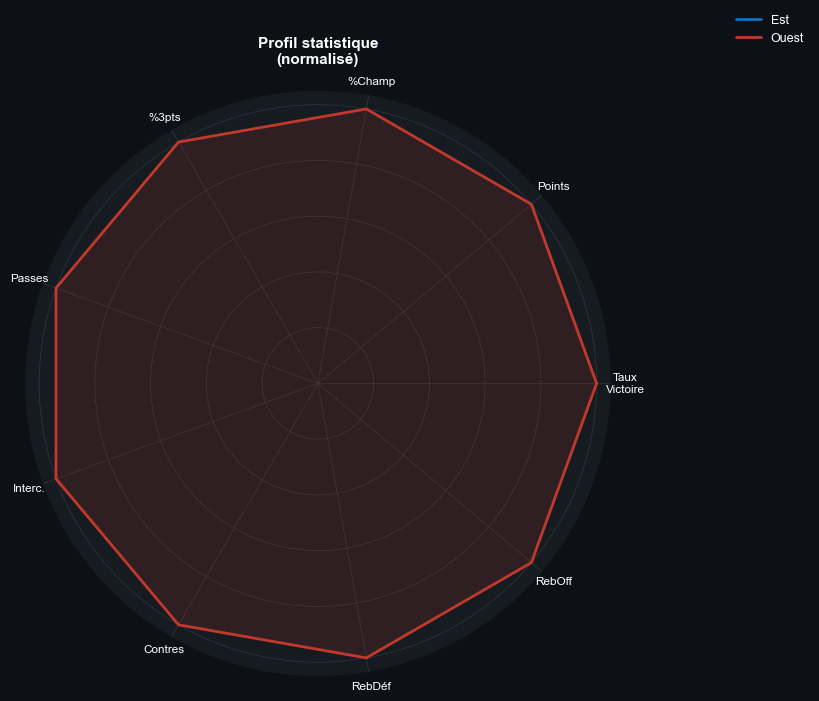

In [26]:
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
ax = fig.add_subplot(121, polar=True)
ax.set_facecolor('#161b22')
ax.spines['polar'].set_color('#30363d')
ax.grid(color='#30363d', linewidth=0.5)
ax.tick_params(colors='#aaaaaa')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, color='white', size=8.5)
ax.set_yticklabels([])

for conf, color in CONF_COLORS.items():
    vals = normed.loc[conf].tolist() + [normed.loc[conf].tolist()[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=conf)
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_title('Profil statistique\n(normalisé)',
              color='white', fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
           labelcolor='white', facecolor='#0d1117',
           edgecolor='#30363d', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "team_radar_chart.png"), dpi=1080, bbox_inches='tight')
plt.show()

#### Barres comparatives

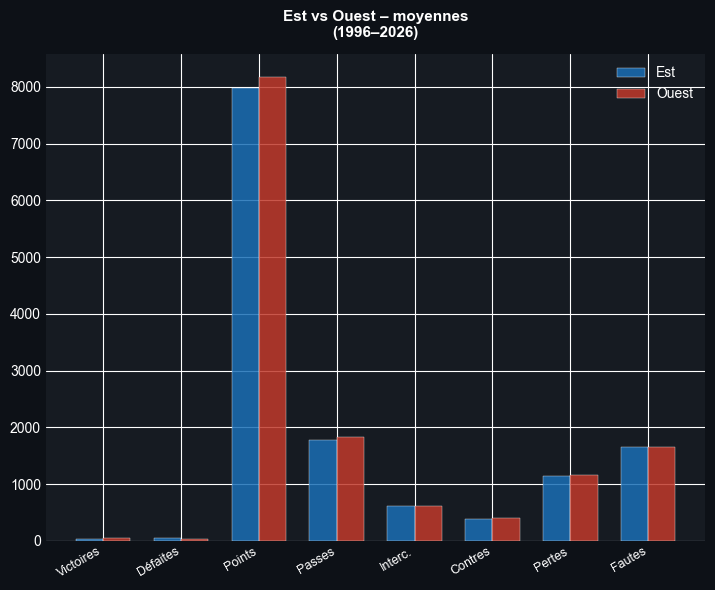

In [27]:
fig1 = plt.figure(figsize=(14, 6))
fig1.patch.set_facecolor('#0d1117')
ax = fig1.add_subplot(122)
ax.set_facecolor('#161b22')

compare_stats  = ['w','l','pts','ast','stl','blk','tov','pf']
compare_labels = ['Victoires','Défaites','Points','Passes',
                  'Interc.','Contres','Pertes','Fautes']

x = np.arange(len(compare_stats))
w = 0.35
est_vals  = [df_confer_96[df_confer_96['confi']=='Est'][s].mean()   for s in compare_stats]
west_vals = [df_confer_96[df_confer_96['confi']=='Ouest'][s].mean() for s in compare_stats]

ax.bar(x - w/2, est_vals,  w, label='Est',   color=CONF_COLORS['Est'],
        alpha=0.85, edgecolor='white', linewidth=0.3)
ax.bar(x + w/2, west_vals, w, label='Ouest', color=CONF_COLORS['Ouest'],
        alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(compare_labels, color='white', fontsize=9,
                    rotation=30, ha='right')
ax.set_title('Est vs Ouest – moyennes\n(1996–2026)',
              color='white', fontsize=11, fontweight='bold', pad=12)
ax.tick_params(colors='white')
ax.legend(labelcolor='white', facecolor='#0d1117', edgecolor='#30363d')
for spine in ax.spines.values():
    spine.set_color('#30363d')

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "conference_comparison.png"), dpi=1080, bbox_inches='tight')
plt.show()

#### taux de qualification playoffs 

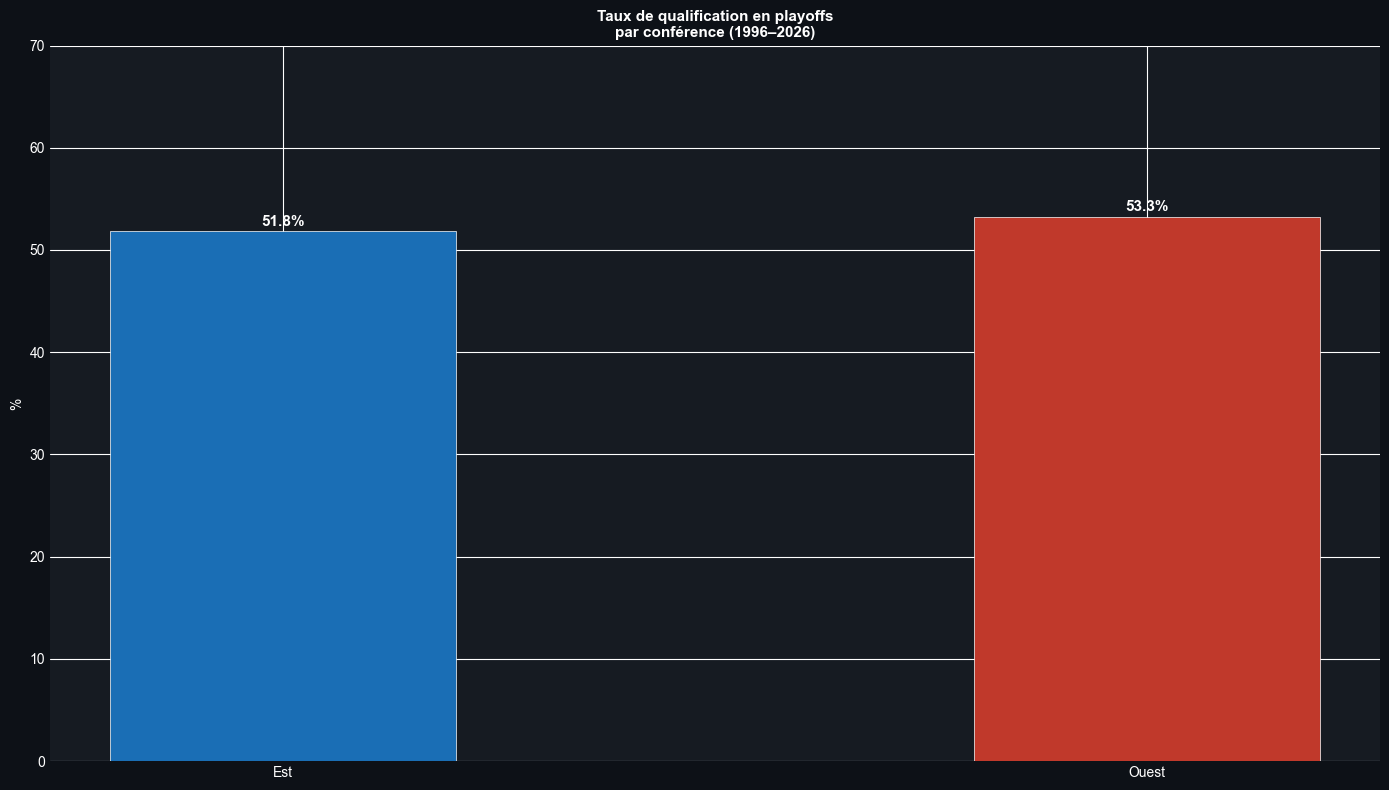

✅ Sauvegardé : playoff_qualification.png


In [28]:
#  Barres : taux de qualification playoffs 

fig3, axes = plt.subplots(figsize=(14, 8))
fig3.patch.set_facecolor('#0d1117')
ax = axes   
ax.set_facecolor('#161b22')

po_rate = df_confer_96.groupby('confi')['playoffs'].mean() * 100
bar_colors_list = [CONF_COLORS[c] for c in po_rate.index]

bars = ax.bar(po_rate.index, po_rate.values,
               color=bar_colors_list, edgecolor='white', linewidth=0.5, width=0.4)

for bar, val in zip(bars, po_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
             f'{val:.1f}%', ha='center', color='white',
             fontweight='bold', fontsize=11)

ax.set_title('Taux de qualification en playoffs\npar conférence (1996–2026)',
              color='white', fontsize=11, fontweight='bold')
ax.tick_params(colors='white')
ax.set_ylabel('%', color='white')
ax.set_ylim(0, 70)
for spine in ax.spines.values():
    spine.set_color('#30363d')

plt.tight_layout()
    
plt.savefig(os.path.join(NBA_Analysis, "playoff_qualification.png"), dpi=1080, bbox_inches='tight', facecolor=fig3.get_facecolor())
plt.show()
print("✅ Sauvegardé : playoff_qualification.png")

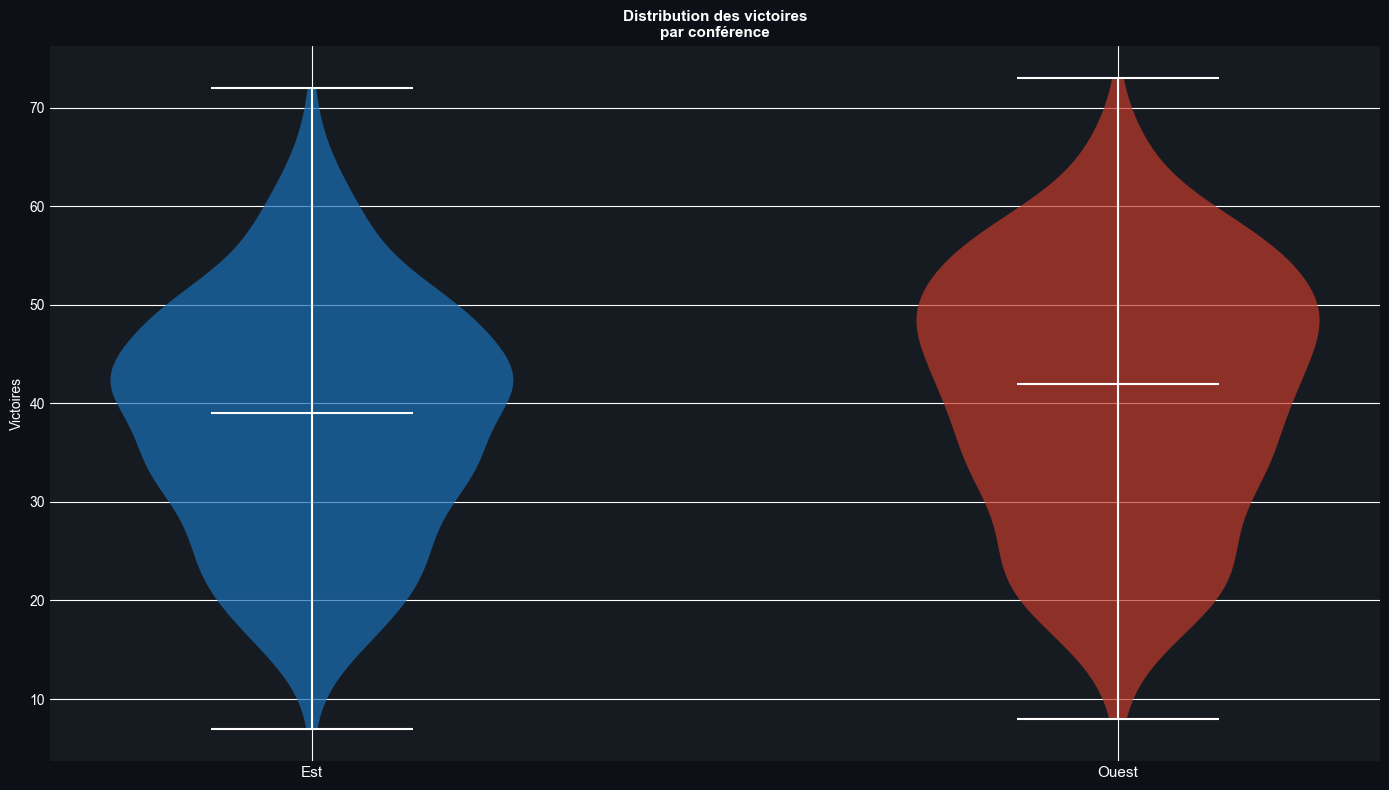

✅ Sauvegardé : victory_distribution.png

=== STATISTIQUES DE VICTOIRES PAR CONFÉRENCE (1996–2026) ===

Est :
  - Moyenne : 38.2 victoires
  - Médiane : 39.0 victoires
  - Écart-type : 12.2 victoires
  - Min : 7.0 victoires
  - Max : 72.0 victoires

Ouest :
  - Moyenne : 40.8 victoires
  - Médiane : 42.0 victoires
  - Écart-type : 13.2 victoires
  - Min : 8.0 victoires
  - Max : 73.0 victoires



In [29]:
fig4, axes = plt.subplots(figsize=(14, 8))
fig4.patch.set_facecolor('#0d1117')

# ── Violin plot : distribution des victoires ──────────────────────────────
ax = axes
ax.set_facecolor('#161b22')

data_e = df_confer_96[df_confer_96['confi'] == 'Est']['w'].dropna()
data_w = df_confer_96[df_confer_96['confi'] == 'Ouest']['w'].dropna()

parts = ax.violinplot([data_e, data_w], positions=[1, 2],
                      showmedians=True, showmeans=False)

for pc, c in zip(parts['bodies'], [CONF_COLORS['Est'], CONF_COLORS['Ouest']]):
    pc.set_facecolor(c)
    pc.set_alpha(0.7)

for key in ('cmedians', 'cbars', 'cmins', 'cmaxes'):
    parts[key].set_color('white')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Est', 'Ouest'], color='white', fontsize=11)
ax.tick_params(colors='white')
ax.set_title('Distribution des victoires\npar conférence',
             color='white', fontsize=11, fontweight='bold')
ax.set_ylabel('Victoires', color='white')
for spine in ax.spines.values():
    spine.set_color('#30363d')
plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "victory_distribution.png"), dpi=1080, bbox_inches='tight', facecolor=fig4.get_facecolor())
plt.show()
print("✅ Sauvegardé : victory_distribution.png")
print("\n=== STATISTIQUES DE VICTOIRES PAR CONFÉRENCE (1996–2026) ===\n")
for conf in ['Est', 'Ouest']:
    conf_data = df_confer_96[df_confer_96['confi'] == conf]['w'].dropna()
    print(f"{conf} :")
    print(f"  - Moyenne : {conf_data.mean():.1f} victoires")
    print(f"  - Médiane : {conf_data.median():.1f} victoires")
    print(f"  - Écart-type : {conf_data.std():.1f} victoires")
    print(f"  - Min : {conf_data.min()} victoires")
    print(f"  - Max : {conf_data.max()} victoires\n")



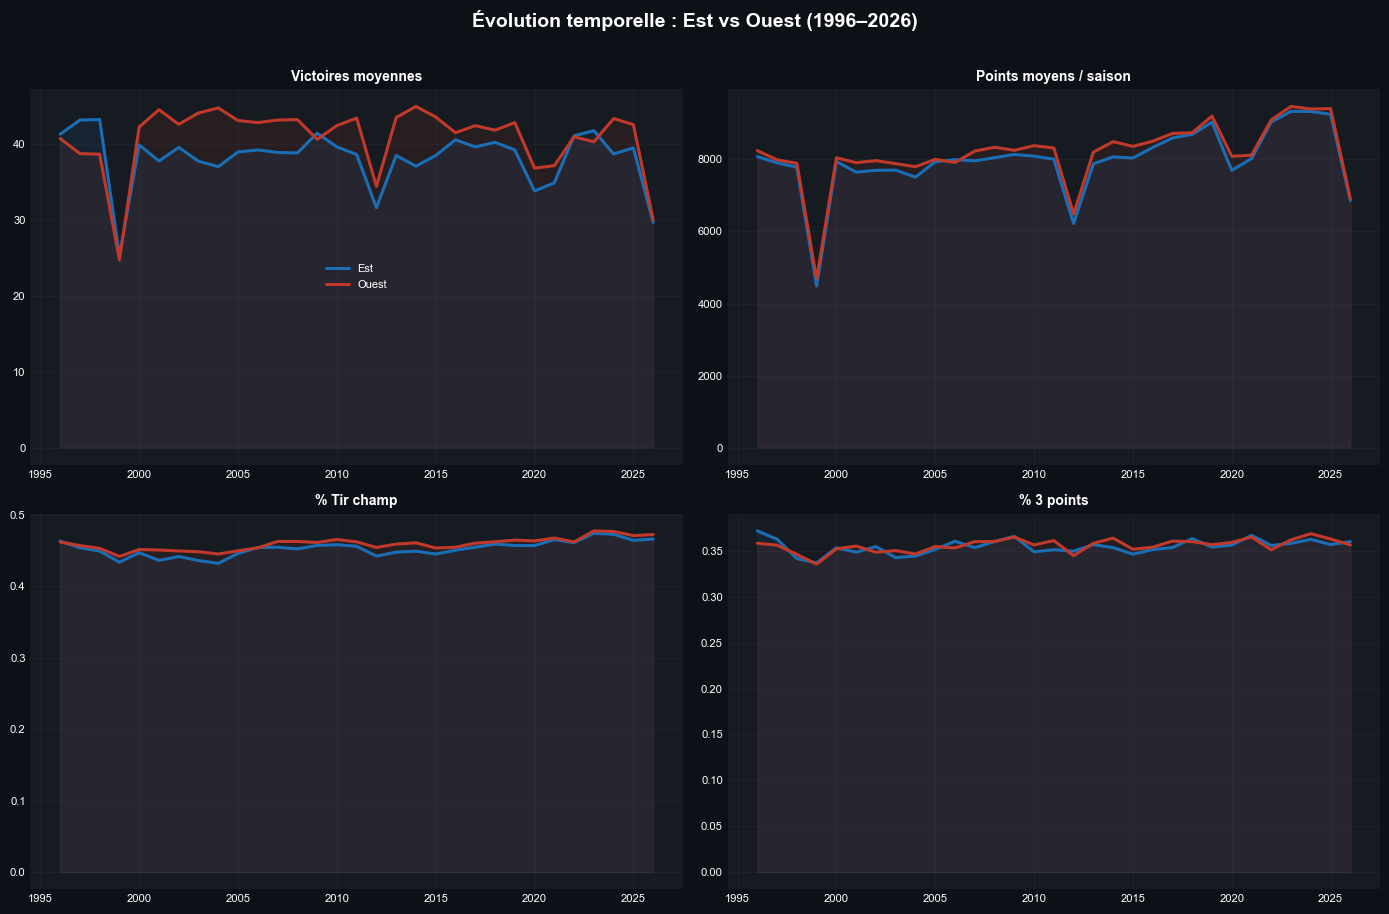

✅ Sauvegardé : fig4_temporal_evolution.png


In [30]:
# ── Agrégation par saison et conférence ───────────────────────────────────
yearly = df_confer_96.groupby(['season', 'confi'])[
    ['w', 'pts', 'fg_percent', 'x3p_percent']
].mean().reset_index()

# ── Figure 2×2 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(
    'Évolution temporelle : Est vs Ouest (1996–2026)',
    color='white', fontsize=14, fontweight='bold', y=1.01
)

panels = [
    ('w',           'Victoires moyennes'),
    ('pts',         'Points moyens / saison'),
    ('fg_percent',  '% Tir champ'),
    ('x3p_percent', '% 3 points'),
]

for ax, (stat, title) in zip(axes.flat, panels):
    ax.set_facecolor('#161b22')

    for conf, color in CONF_COLORS.items():
        sub = yearly[yearly['confi'] == conf]
        ax.plot(sub['season'], sub[stat],
                color=color, linewidth=2.2, label=conf)
        ax.fill_between(sub['season'], sub[stat], alpha=0.1, color=color)

    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#30363d')
    ax.grid(color='#30363d', linewidth=0.4, alpha=0.5)

    # Légende sur le premier panneau seulement
    if stat == 'w':
        ax.legend(labelcolor='white', facecolor='#0d1117',
                  edgecolor='#30363d', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "fig4_temporal_evolution.png"), dpi=1080, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Sauvegardé : fig4_temporal_evolution.png")

### Score de dominance composite

In [31]:

# 40% Win Rate + 35% Taux Playoffs + 25% Points
team_stats = df_confer_96.groupby(['team', 'confi']).agg(
    saisons       = ('season',  'count'),
    victoires_tot = ('w',       'sum'),
    defaites_tot  = ('l',       'sum'),
    win_rate_moy  = ('win_rate','mean'),
    pts_moy       = ('pts',     'mean'),
    playoffs_tot  = ('playoffs','sum'),
    ast_moy       = ('ast',     'mean'),
    blk_moy       = ('blk',     'mean'),
    stl_moy       = ('stl',     'mean'),
).reset_index()

team_stats['playoffs_rate'] = team_stats['playoffs_tot'] / team_stats['saisons']
team_stats['score'] = (
    team_stats['win_rate_moy']  * 0.40 +
    team_stats['playoffs_rate'] * 0.35 +
    (team_stats['pts_moy'] / team_stats['pts_moy'].max()) * 0.25
)

top_est   = team_stats[team_stats['confi'] == 'Est'  ].nlargest(10, 'score').reset_index(drop=True)
top_ouest = team_stats[team_stats['confi'] == 'Ouest'].nlargest(10, 'score').reset_index(drop=True)

# ── Palettes & style ──────────────────────────────────────────────────────
colors_e = ['#1a6eb5','#2980b9','#3498db','#5dade2','#85c1e9',
            '#aed6f1','#d6eaf8','#c8d6e5','#b0c4de','#9bb7d4']
colors_o = ['#c0392b','#e74c3c','#ec7063','#f1948a','#f5b7b1',
            '#fadbd8','#f9c0bb','#f4b8b0','#eea9a0','#e89a90']
BG   = '#0d1117'
CARD = '#161b22'
GRID = '#30363d'



#### Classement dominance (barres horizontales)

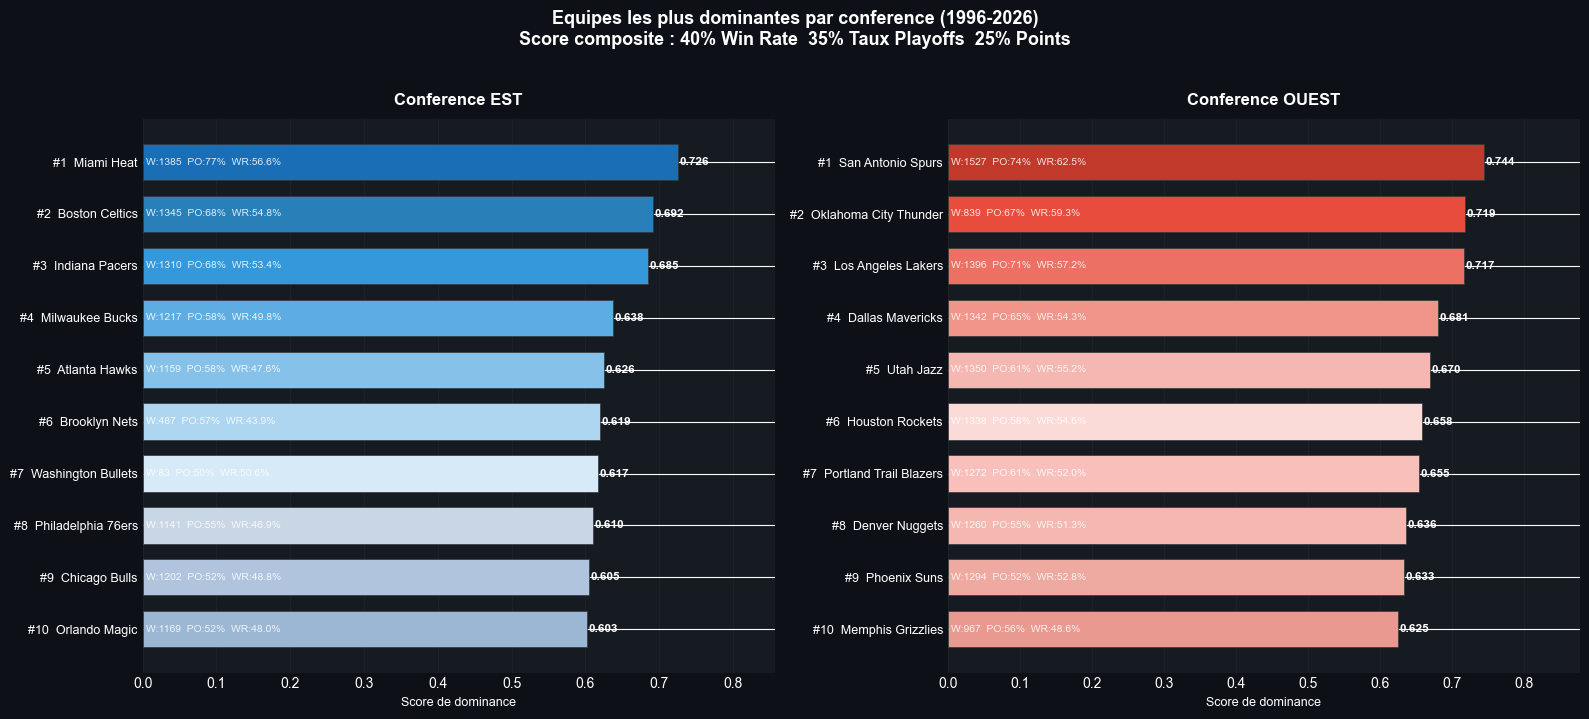

Sauvegarde : fig6a_dominance_ranking.png

✅ Classement de dominance composite calculé et visualisé
                 team     score  win_rate_moy  playoffs_rate      pts_moy
0          Miami Heat  0.726021      0.566195       0.774194  7899.709677
1      Boston Celtics  0.691590      0.548383       0.677419  8126.580645
2      Indiana Pacers  0.684572      0.534098       0.677419  8081.516129
3     Milwaukee Bucks  0.637893      0.498225       0.580645  8134.774194
4       Atlanta Hawks  0.625650      0.475624       0.580645  8024.096774
5       Brooklyn Nets  0.619391      0.439351       0.571429  8420.714286
6  Washington Bullets  0.616946      0.506098       0.500000  8277.500000
7  Philadelphia 76ers  0.609829      0.469070       0.548387  7958.129032
8       Chicago Bulls  0.604587      0.488317       0.516129  7901.096774
9       Orlando Magic  0.602533      0.479505       0.516129  7951.903226
                     team     score  win_rate_moy  playoffs_rate      pts_moy
0       S

In [32]:
# Figure A – Classement de dominance composite
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle(
    'Equipes les plus dominantes par conference (1996-2026)\n'
    'Score composite : 40% Win Rate  35% Taux Playoffs  25% Points',
    color='white', fontsize=13, fontweight='bold', y=1.02
)

for ax, top, conf_colors, conf_label in [
    (ax1, top_est,   colors_e, 'Conference EST'),
    (ax2, top_ouest, colors_o, 'Conference OUEST'),
]:
    ax.set_facecolor(CARD)
    bars = ax.barh(range(len(top)), top['score'],
                   color=conf_colors, edgecolor=GRID, linewidth=0.5, height=0.7)

    for bar, row in zip(bars, top.itertuples()):
        # Score à droite
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{row.score:.3f}', va='center', color='white',
                fontsize=8.5, fontweight='bold')
        # Stats inline
        ax.text(0.005, bar.get_y() + bar.get_height() / 2,
                f'W:{row.victoires_tot:.0f}  PO:{row.playoffs_rate*100:.0f}%  WR:{row.win_rate_moy*100:.1f}%',
                va='center', color='white', fontsize=7.5, alpha=0.85)

    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f"#{i+1}  {t}" for i, t in enumerate(top['team'])],
                       color='white', fontsize=9)
    ax.invert_yaxis()
    ax.set_title(conf_label, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='white')
    ax.set_xlabel('Score de dominance', color='white', fontsize=9)
    for spine in ax.spines.values(): spine.set_color(GRID)
    ax.set_xlim(0, top['score'].max() * 1.18)
    ax.grid(axis='x', color=GRID, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "dominance_ranking.png"), dpi=2160, bbox_inches='tight', facecolor=BG)
plt.show()
print("Sauvegarde : fig6a_dominance_ranking.png")
print("\n✅ Classement de dominance composite calculé et visualisé")
print(top_est[['team', 'score', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])
print(top_ouest[['team', 'score', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])



### Bubble chart : Win Rate vs Taux Playoffs

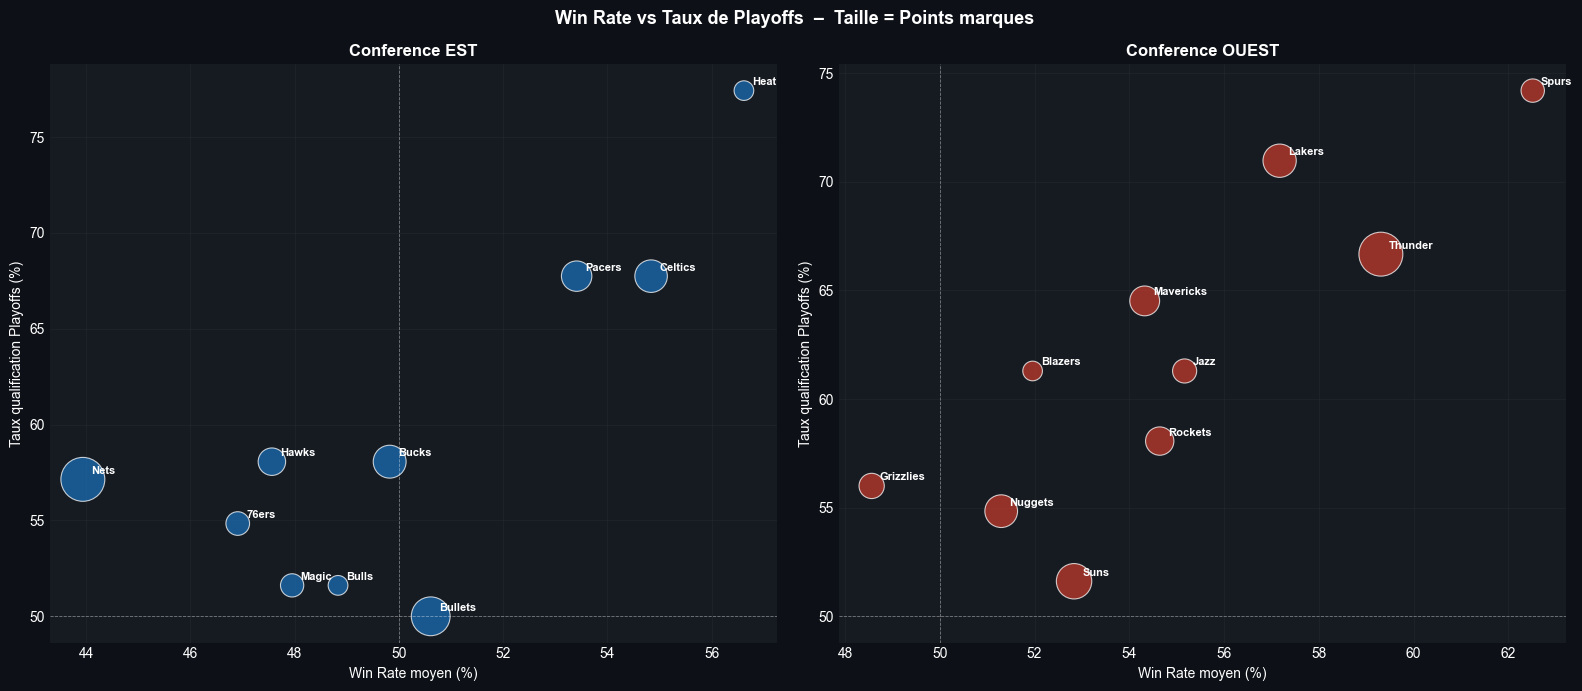

Sauvegarde : fig6b_bubble_dominance.png

✅ Analyse de dominance visuelle créée
Top équipes de l'Est :
                 team  win_rate_moy  playoffs_rate      pts_moy
0          Miami Heat      0.566195       0.774194  7899.709677
1      Boston Celtics      0.548383       0.677419  8126.580645
2      Indiana Pacers      0.534098       0.677419  8081.516129
3     Milwaukee Bucks      0.498225       0.580645  8134.774194
4       Atlanta Hawks      0.475624       0.580645  8024.096774
5       Brooklyn Nets      0.439351       0.571429  8420.714286
6  Washington Bullets      0.506098       0.500000  8277.500000
7  Philadelphia 76ers      0.469070       0.548387  7958.129032
8       Chicago Bulls      0.488317       0.516129  7901.096774
9       Orlando Magic      0.479505       0.516129  7951.903226

Top équipes de l'Ouest :
                     team  win_rate_moy  playoffs_rate      pts_moy
0       San Antonio Spurs      0.625140       0.741935  8091.677419
1   Oklahoma City Thunder      0

In [33]:
# FIGURE B – Win Rate vs Taux de Playoffs (Bubble Chart)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle('Win Rate vs Taux de Playoffs  –  Taille = Points marques',
             color='white', fontsize=13, fontweight='bold')

for ax, top, c, label in [
    (ax1, top_est,   '#1a6eb5', 'Conference EST'),
    (ax2, top_ouest, '#c0392b', 'Conference OUEST'),
]:
    ax.set_facecolor(CARD)
    sizes = ((top['pts_moy'] - top['pts_moy'].min()) /
             (top['pts_moy'].max() - top['pts_moy'].min()) * 800 + 200)

    ax.scatter(top['win_rate_moy'] * 100, top['playoffs_rate'] * 100,
               s=sizes, color=c, alpha=0.75, edgecolors='white', linewidth=0.8)

    for _, row in top.iterrows():
        name = row['team'].split()[-1]
        ax.annotate(name,
                    (row['win_rate_moy'] * 100, row['playoffs_rate'] * 100),
                    textcoords='offset points', xytext=(6, 4),
                    color='white', fontsize=8, fontweight='bold')

    ax.set_xlabel('Win Rate moyen (%)', color='white', fontsize=10)
    ax.set_ylabel('Taux qualification Playoffs (%)', color='white', fontsize=10)
    ax.set_title(label, color='white', fontsize=12, fontweight='bold')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_color(GRID)
    ax.grid(color=GRID, linewidth=0.4, alpha=0.5)
    ax.axhline(50, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
    ax.axvline(50, color='white', linewidth=0.6, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "bubble_dominance.png"), dpi=2160, bbox_inches='tight', facecolor=BG)
plt.show()
print("Sauvegarde : fig6b_bubble_dominance.png")
print("\n✅ Analyse de dominance visuelle créée")
print("Top équipes de l'Est :")
print(top_est[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])
print("\nTop équipes de l'Ouest :")
print(top_ouest[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])



### Evolution annuelle des victoires (Top 3 par conf.)

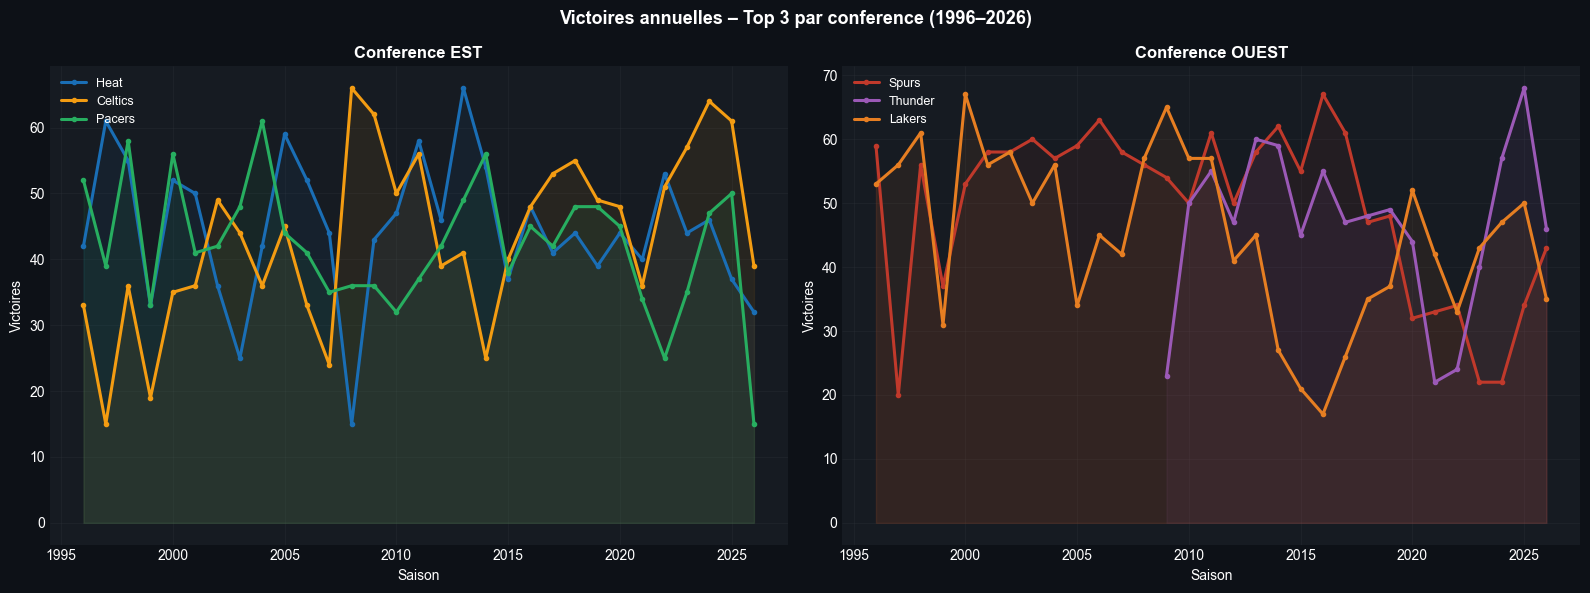

Sauvegarde : fig6c_top3_evolution.png

✅ Evolution des victoires des équipes les plus dominantes visualisée
Top 3 équipes de l'Est :
             team  win_rate_moy  playoffs_rate      pts_moy
0      Miami Heat      0.566195       0.774194  7899.709677
1  Boston Celtics      0.548383       0.677419  8126.580645
2  Indiana Pacers      0.534098       0.677419  8081.516129

Top 3 équipes de l'Ouest :
                    team  win_rate_moy  playoffs_rate      pts_moy
0      San Antonio Spurs      0.625140       0.741935  8091.677419
1  Oklahoma City Thunder      0.593087       0.666667  8569.166667
2     Los Angeles Lakers      0.571720       0.709677  8285.354839


In [34]:
# FIGURE C – Evolution des victoires annuelles des top 3 par conference

top3_est   = top_est.head(3)['team'].tolist()
top3_ouest = top_ouest.head(3)['team'].tolist()
yearly     = df_confer_96.groupby(['season', 'team'])['w'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Victoires annuelles – Top 3 par conference (1996–2026)',
             color='white', fontsize=13, fontweight='bold')

palette_e = ['#1a6eb5', '#f39c12', '#27ae60']
palette_o = ['#c0392b', '#9b59b6', '#e67e22']

for ax, top3, palette, label in [
    (ax1, top3_est,   palette_e, 'Conference EST'),
    (ax2, top3_ouest, palette_o, 'Conference OUEST'),
]:
    ax.set_facecolor(CARD)
    for team, color in zip(top3, palette):
        sub = yearly[yearly['team'] == team]
        ax.plot(sub['season'], sub['w'], color=color, linewidth=2.2,
                label=team.split()[-1], marker='o', markersize=3)
        ax.fill_between(sub['season'], sub['w'], alpha=0.08, color=color)

    ax.set_title(label, color='white', fontsize=12, fontweight='bold')
    ax.tick_params(colors='white')
    ax.set_ylabel('Victoires', color='white')
    ax.set_xlabel('Saison', color='white')
    for spine in ax.spines.values(): spine.set_color(GRID)
    ax.grid(color=GRID, linewidth=0.4, alpha=0.5)
    ax.legend(labelcolor='white', facecolor=BG, edgecolor=GRID, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "top3_evolution_EST_VS_OUEST.png"), dpi=2160, bbox_inches='tight', facecolor=BG)
plt.show()
print("Sauvegarde : fig6c_top3_evolution.png")
print("\n✅ Evolution des victoires des équipes les plus dominantes visualisée")
print("Top 3 équipes de l'Est :")
print(top_est.head(3)[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])
print("\nTop 3 équipes de l'Ouest :")
print(top_ouest.head(3)[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])



### Heatmap victoires par equipe et decennie

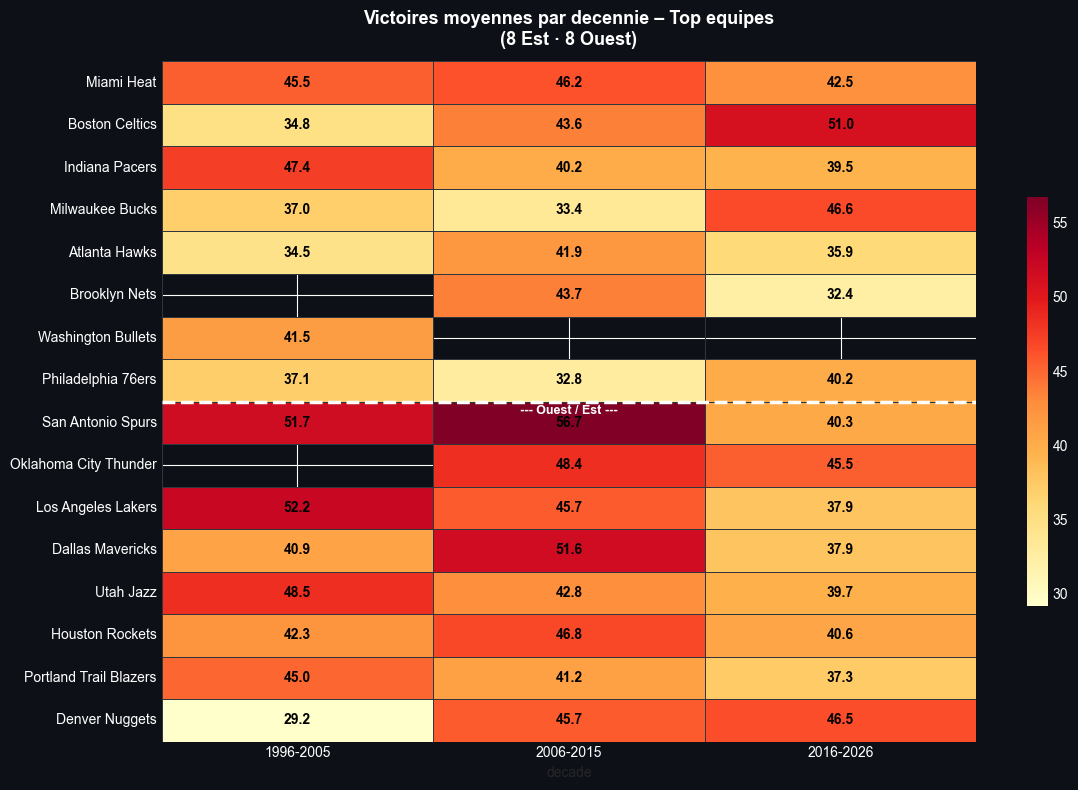

Sauvegarde : fig6d_decade_heatmap.png

✅ Heatmap des victoires par équipe et décennie créée
Victoires moyennes par décennie pour les équipes de l'Est :
                 team  win_rate_moy  playoffs_rate      pts_moy
0          Miami Heat      0.566195       0.774194  7899.709677
1      Boston Celtics      0.548383       0.677419  8126.580645
2      Indiana Pacers      0.534098       0.677419  8081.516129
3     Milwaukee Bucks      0.498225       0.580645  8134.774194
4       Atlanta Hawks      0.475624       0.580645  8024.096774
5       Brooklyn Nets      0.439351       0.571429  8420.714286
6  Washington Bullets      0.506098       0.500000  8277.500000
7  Philadelphia 76ers      0.469070       0.548387  7958.129032

Victoires moyennes par décennie pour les équipes de l'Ouest :
                     team  win_rate_moy  playoffs_rate      pts_moy
0       San Antonio Spurs      0.625140       0.741935  8091.677419
1   Oklahoma City Thunder      0.593087       0.666667  8569.166667
2    

In [35]:
# FIGURE D – Heatmap victoires par equipe et decennie

df_confer_96['decade'] = pd.cut(
    df_confer_96['season'],
    bins=[1995, 2005, 2015, 2026],
    labels=['1996-2005', '2006-2015', '2016-2026']
)

all_top = pd.concat([top_est.head(8), top_ouest.head(8)])['team'].tolist()
pivot   = df_confer_96[df_confer_96['team'].isin(all_top)].groupby(['team', 'decade'])['w'].mean().unstack()
pivot   = pivot.reindex(all_top)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor=GRID, ax=ax,
            annot_kws={'size': 10, 'color': 'black', 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.6})

ax.axhline(8, color='white', linewidth=2.5, linestyle='--')
ax.text(1.5, 8.3, '--- Ouest / Est ---', color='white',
        fontsize=9, ha='center', fontweight='bold')

ax.set_title('Victoires moyennes par decennie – Top equipes\n(8 Est · 8 Ouest)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('')
ax.tick_params(colors='white', labelsize=10)
ax.figure.axes[-1].tick_params(colors='white')

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "decade_heatmap.png"), dpi=1080, bbox_inches='tight', facecolor=BG)
plt.show()
print("Sauvegarde : fig6d_decade_heatmap.png")
print("\n✅ Heatmap des victoires par équipe et décennie créée")
print("Victoires moyennes par décennie pour les équipes de l'Est :")
print(top_est.head(8)[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])
print("\nVictoires moyennes par décennie pour les équipes de l'Ouest :")
print(top_ouest.head(8)[['team', 'win_rate_moy', 'playoffs_rate', 'pts_moy']])


### ANALYSE GLOBALE : CORRÉLATIONS

In [36]:
def plot_correlation_matrix(data):
    feat_cols = ['w','pts','fg_percent','x3p_percent','ft_percent','orb','drb','ast','stl','blk','tov','pf','age']
    feat_labels = ['Victoires','Points','%Champ','%3pts','%LF','RebOff','RebDéf','Passes','Interc.','Contres','Pertes','Fautes','Âge']
    
    corr = data[feat_cols].corr()
    fig, ax = plt.subplots(figsize=(11, 9), facecolor=BG_COLOR)
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(220, 10, as_cmap=True)

    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, 
                xticklabels=feat_labels, yticklabels=feat_labels, ax=ax,
                annot_kws={'size': 8.5}, cbar_kws={'shrink': 0.8})

    ax.set_title('Matrice de corrélation (Prédicteurs de victoires)', fontsize=14, fontweight='bold', pad=15)
    plt.savefig('fig1_correlation_matrix.png', dpi=1080, bbox_inches='tight')
    plt.show()

# Analyse des joueurs

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

output_dir = "images_players"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    # 1. Chargement et Nettoyage
try:
    df = pd.read_csv('Player Totals.csv', sep=';', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('Player Totals.csv', sep=';', encoding='latin-1')

# Conversion en numérique et gestion des valeurs manquantes
cols = ['pts', 'trb', 'ast', 'stl', 'blk', 'g']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

### ANALYSE  : HISTOGRAMME TOP 10 Meilleurs Marqueurs ALL TIME 

🏆 Top 10 Meilleurs Marqueurs de l'Histoire :
player
LeBron James           43066
Kareem Abdul-Jabbar    38387
Karl Malone            36928
Wilt Chamberlain       33953
Kobe Bryant            33643
Kevin Durant           33404
James Harden           32702
Michael Jordan         32292
Eddie Johnson          31852
Dirk Nowitzki          31560


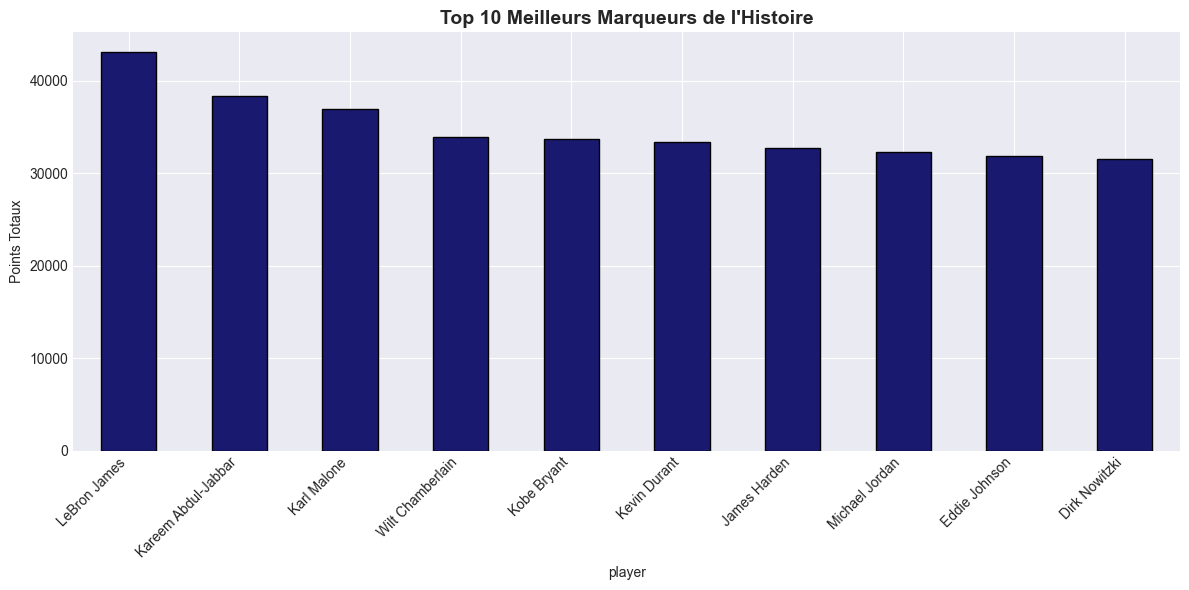

In [38]:
top_10_all_time = df.groupby('player')['pts'].sum().sort_values(ascending=False).head(10)
print("🏆 Top 10 Meilleurs Marqueurs de l'Histoire :")
print(top_10_all_time.to_string())

plt.figure(figsize=(12, 6))
top_10_all_time.plot(kind='bar', color='midnightblue', edgecolor='black')
plt.title("Top 10 Meilleurs Marqueurs de l'Histoire", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Points Totaux')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_10_all_time.png"), dpi=2160, bbox_inches='tight')
plt.show()

## ANALYSE 2 : PRÉPARATION DONNÉES 2026

In [39]:
df_2026 = df[df['season'] == 2026].copy()

# Calcul des moyennes par match (indispensable pour l'affichage final)
df_2026['pts_g'] = df_2026['pts'] / df_2026['g'].replace(0, 1)
df_2026['trb_g'] = df_2026['trb'] / df_2026['g'].replace(0, 1)
df_2026['ast_g'] = df_2026['ast'] / df_2026['g'].replace(0, 1)
df_2026['stl_g'] = df_2026['stl'] / df_2026['g'].replace(0, 1)
df_2026['blk_g'] = df_2026['blk'] / df_2026['g'].replace(0, 1)
# CRÉATION DE LA COLONNE MANQUANTE 'composite' 
# On définit le score All-Star comme la somme des stats moyennes
df_2026['composite'] = df_2026['pts_g'] + df_2026['trb_g'] + df_2026['ast_g'] + df_2026['stl_g'] + df_2026['blk_g']

####  TOP 5 DÉFENSEURS 2026


🛡️ Top 5 défenseurs 2026 (steals + blocks par match) :
           player    stl_g    blk_g  defense
Victor Wembanyama 0.977778 2.844444 3.822222
   Walker Kessler 1.400000 1.800000 3.200000
     John Konchar 2.375000 0.750000 3.125000
  Dejounte Murray 2.500000 0.500000 3.000000
Scotty Pippen Jr. 2.428571 0.571429 3.000000


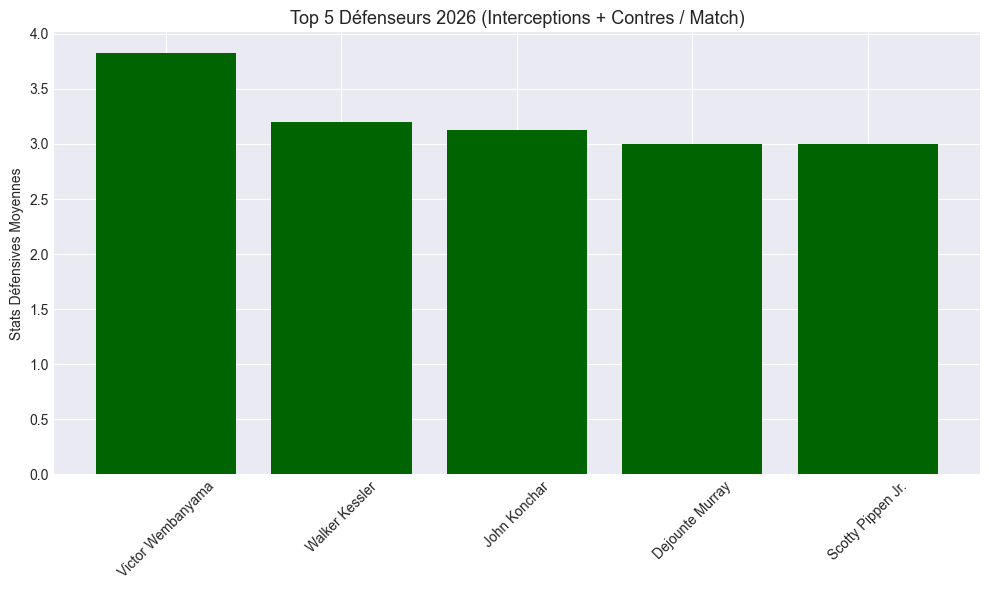

In [40]:
df_2026['defense'] = df_2026['stl_g'] + df_2026['blk_g']
top_defenders = df_2026.nlargest(5, 'defense')
print("\n🛡️ Top 5 défenseurs 2026 (steals + blocks par match) :")
print(top_defenders[['player', 'stl_g', 'blk_g', 'defense']].to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(top_defenders['player'], top_defenders['defense'], color='darkgreen')
plt.title('Top 5 Défenseurs 2026 (Interceptions + Contres / Match)', fontsize=13)
plt.ylabel('Stats Défensives Moyennes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "TOP 5 DÉFENSEURS 2026.png"), dpi=1080, bbox_inches='tight')
plt.show()



### top 10 Joueurs les plus complets en 2026 (composite)


⭐ Top 10 Joueurs les plus complets en 2026 (composite) :
                 player     pts_g     trb_g     ast_g    stl_g    blk_g  composite
           Nikola Joki? 28.659091 12.613636 10.500000 1.386364 0.727273  53.886364
            Luka Don?i? 32.574468  7.723404  8.617021 1.425532 0.489362  50.829787
  Giannis Antetokounmpo 27.966667 10.033333  5.600000 0.900000 0.733333  45.233333
Shai Gilgeous-Alexander 31.880000  4.420000  6.460000 1.320000 0.800000  44.880000
        Cade Cunningham 25.403846  5.807692  9.769231 1.500000 0.961538  43.442308
          Jalen Johnson 23.018519 10.611111  7.944444 1.314815 0.500000  43.388889
           Tyrese Maxey 29.070175  4.140351  6.807018 2.052632 0.771930  42.842105
           Jaylen Brown 29.075472  7.113208  4.924528 1.018868 0.452830  42.584906
      Victor Wembanyama 23.688889 11.155556  2.933333 0.977778 2.844444  41.600000
        Anthony Edwards 29.620000  5.240000  3.680000 1.360000 0.800000  40.700000


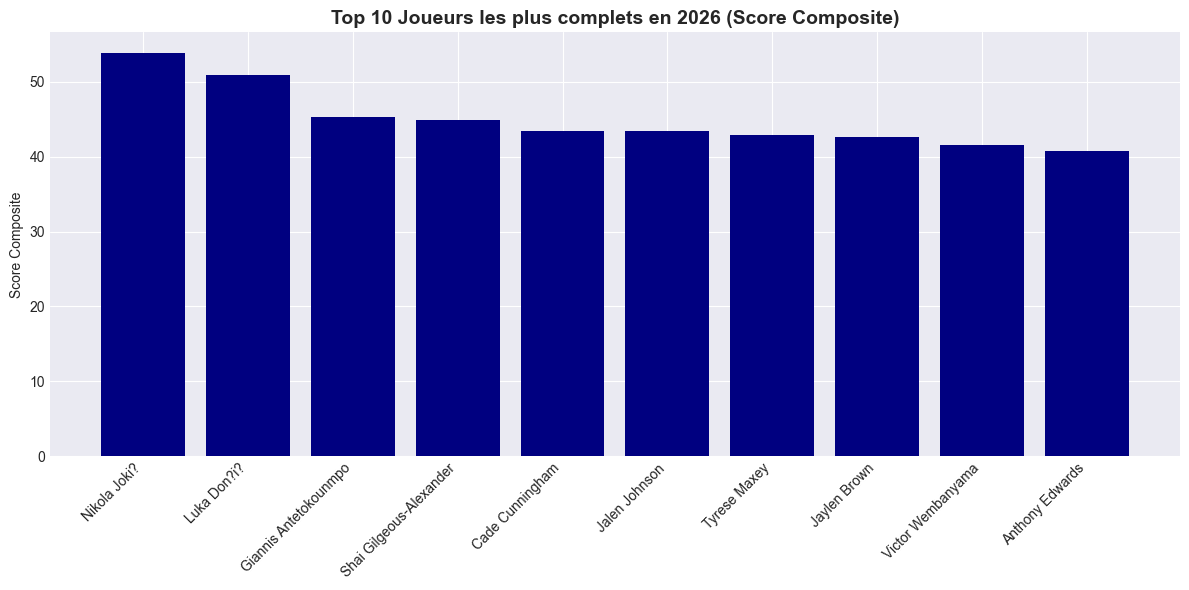

In [41]:
top_10_2026 = df_2026.nlargest(10, 'composite')
print("\n⭐ Top 10 Joueurs les plus complets en 2026 (composite) :")
print(top_10_2026[['player', 'pts_g', 'trb_g', 'ast_g', 'stl_g', 'blk_g', 'composite']].to_string(index=False))
plt.figure(figsize=(12, 6))
plt.bar(top_10_2026['player'], top_10_2026['composite'], color='navy')
plt.title('Top 10 Joueurs les plus complets en 2026 (Score Composite)', fontsize=14, fontweight='bold')
plt.ylabel('Score Composite')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_10_composite_2026.png"), dpi=1080, bbox_inches='tight')
plt.show()

#### RADAR AVEC JOUEURS SUPPLÉMENTAIRES


📊 Préparation du radar comparatif pour 2026 avec joueurs supplémentaires...


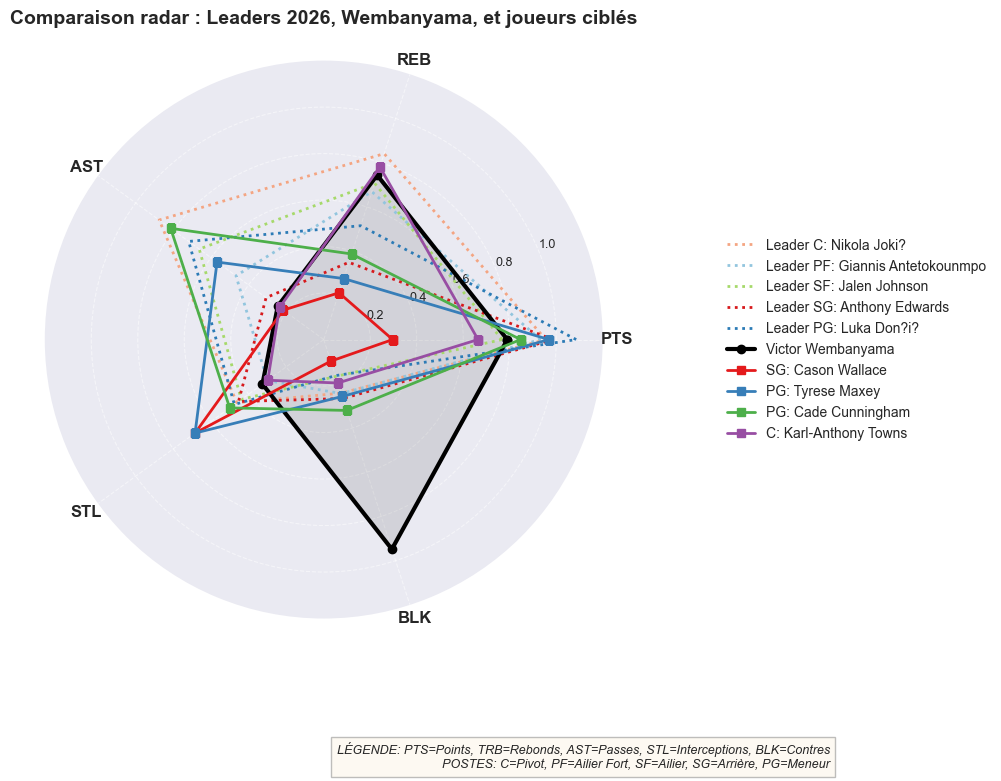


✅ Radar comparatif créé avec les joueurs additionnels


In [42]:
print("\n📊 Préparation du radar comparatif pour 2026 avec joueurs supplémentaires...")
def plot_radar_with_extra():
    positions = ['C', 'PF', 'SF', 'SG', 'PG']
    labels = ['PTS', 'REB', 'AST', 'STL', 'BLK']  # rebonds abrégé
    ref_scales = [30, 15, 12, 3, 3]
    
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    colors_pos = ['#f4a582', '#92c5de', '#a6d96a', '#d7191c', '#2c7bb6']
    
    # Leaders par poste 
    for i, pos in enumerate(positions):
        subset = df_2026[df_2026['pos'] == pos]
        if not subset.empty:
            best = subset.sort_values('composite', ascending=False).iloc[0]
            values = [best['pts_g'], best['trb_g'], best['ast_g'], best['stl_g'], best['blk_g']]
            norm_vals = [min(v / s, 1.2) for v, s in zip(values, ref_scales)]
            norm_vals += norm_vals[:1]
            ax.plot(angles, norm_vals, color=colors_pos[i], linestyle=':', linewidth=2,
                    label=f"Leader {pos}: {best['player']}")
    
    # Victor Wembanyama
    wemb = df_2026[df_2026['player'] == 'Victor Wembanyama']
    if not wemb.empty:
        w = wemb.iloc[0]
        poste_w = w['pos']
        w_vals = [w['pts_g'], w['trb_g'], w['ast_g'], w['stl_g'], w['blk_g']]
        w_norm = [min(v / s, 1.2) for v, s in zip(w_vals, ref_scales)]
        w_norm += w_norm[:1]
        ax.plot(angles, w_norm, color='black', linewidth=3, marker='o', label='Victor Wembanyama')
        ax.fill(angles, w_norm, color='black', alpha=0.1)
    
    # Joueurs additionnels
    extra_players = ['Cason Wallace', 'Tyrese Maxey', 'Cade Cunningham', 'Karl-Anthony Towns']
    extra_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    
    for idx, name in enumerate(extra_players):
        player = df_2026[df_2026['player'] == name]
        if not player.empty:
            p = player.iloc[0]
            poste = p['pos'] 
            vals = [p['pts_g'], p['trb_g'], p['ast_g'], p['stl_g'], p['blk_g']]
            norm_vals = [min(v / s, 1.2) for v, s in zip(vals, ref_scales)]
            norm_vals += norm_vals[:1]
            ax.plot(angles, norm_vals, color=extra_colors[idx], linewidth=2, marker='s',
                    label=f"{poste}: {name}")
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    legend = ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), fontsize=10)
    legend.get_frame().set_alpha(0.9)
    
    # Titre et sous-titre
    plt.subplots_adjust(bottom=0.2, right=0.8)

    plt.title("Comparaison radar : Leaders 2026, Wembanyama, et joueurs ciblés\n", 
              fontsize=14, fontweight='bold')
    plt.figtext(0.80, 0.05, 
                "LÉGENDE: PTS=Points, TRB=Rebonds, AST=Passes, STL=Interceptions, BLK=Contres\n"
                "POSTES: C=Pivot, PF=Ailier Fort, SF=Ailier, SG=Arrière, PG=Meneur",
                ha='right', fontsize=9, style='italic', 
                bbox=dict(facecolor='oldlace', alpha=0.5, edgecolor='gray'))
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/comparison_radar_2026.png", bbox_inches='tight', dpi=1080)
    plt.show()
plot_radar_with_extra()
print("\n✅ Radar comparatif créé avec les joueurs additionnels")

### ALL-STAR


⭐ Classement All-Star 2026 (Top 12) :
                 player     pts_g     trb_g     ast_g    stl_g    blk_g  composite
           Nikola Joki? 28.659091 12.613636 10.500000 1.386364 0.727273  53.886364
            Luka Don?i? 32.574468  7.723404  8.617021 1.425532 0.489362  50.829787
  Giannis Antetokounmpo 27.966667 10.033333  5.600000 0.900000 0.733333  45.233333
Shai Gilgeous-Alexander 31.880000  4.420000  6.460000 1.320000 0.800000  44.880000
        Cade Cunningham 25.403846  5.807692  9.769231 1.500000 0.961538  43.442308
          Jalen Johnson 23.018519 10.611111  7.944444 1.314815 0.500000  43.388889
           Tyrese Maxey 29.070175  4.140351  6.807018 2.052632 0.771930  42.842105
           Jaylen Brown 29.075472  7.113208  4.924528 1.018868 0.452830  42.584906
      Victor Wembanyama 23.688889 11.155556  2.933333 0.977778 2.844444  41.600000
        Anthony Edwards 29.620000  5.240000  3.680000 1.360000 0.800000  40.700000
       Donovan Mitchell 28.545455  4.490909  5.8

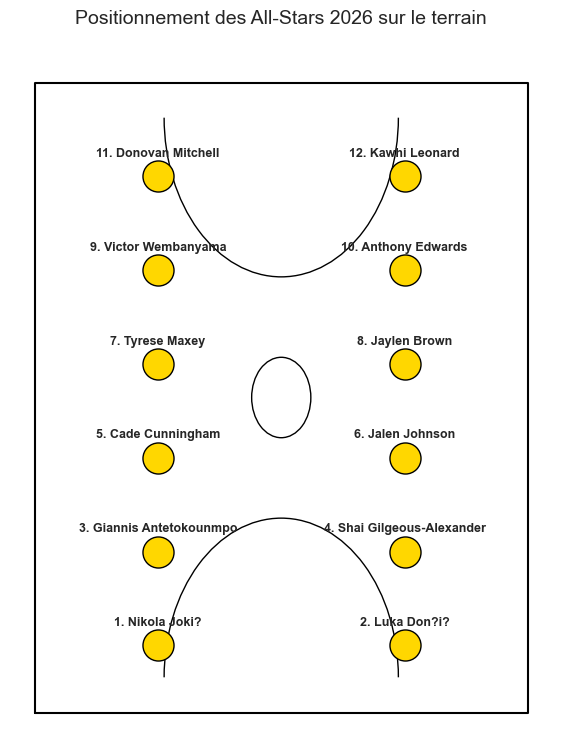

In [43]:

all_stars = df_2026[df_2026['season'] == 2026].nlargest(12, 'composite')

print("\n⭐ Classement All-Star 2026 (Top 12) :")
print(all_stars[['player', 'pts_g', 'trb_g', 'ast_g', 'stl_g', 'blk_g', 'composite']].to_string(index=False))


def dessiner_terrain(ax):
    ax.plot([0, 100, 100, 0, 0], [0, 0, 94, 94, 0], color="black")
    ax.add_patch(patches.Circle((50, 47), 6, fill=False))
    ax.add_patch(patches.Arc((50, 5.25), 47.5, 47.5, theta1=0, theta2=180, fill=False))
    ax.add_patch(patches.Arc((50, 88.75), 47.5, 47.5, theta1=180, theta2=360, fill=False))
    ax.axis('off')

# Sélection du Top 12 
all_stars = df_2026.nlargest(12, 'composite')

fig, ax = plt.subplots(figsize=(7, 9))
dessiner_terrain(ax)

for i, (idx, row) in enumerate(all_stars.iterrows()):
    x = 25 if i % 2 == 0 else 75
    y = 10 + (i // 2) * 14
    ax.scatter(x, y, s=500, color='gold', edgecolors='black', zorder=3)
    ax.text(x, y + 3, f"{i+1}. {row['player']}", ha='center', fontweight='bold', fontsize=9)

plt.title('Positionnement des All-Stars 2026 sur le terrain', pad=20, fontsize=14)
plt.savefig(f"{output_dir}/terrain_all_star_2026.jpg", bbox_inches='tight', dpi=1080)
plt.show()

#### PERFORMANCE PAR MINUTE (ALL-STARS)

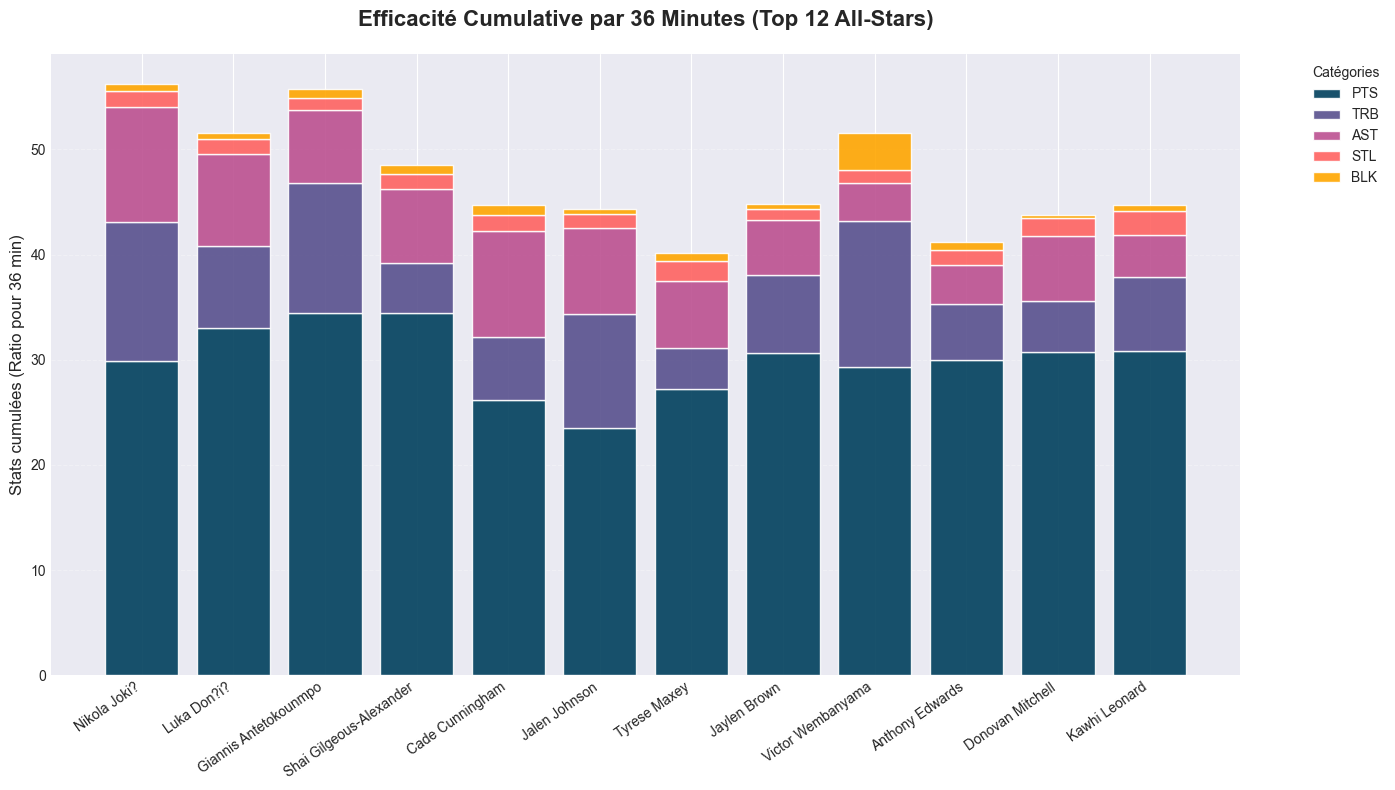

In [44]:

# On calcule l'efficacité pour 36 minutes (standard NBA) pour que les chiffres parlent mieux
all_stars_pm = df_2026.nlargest(12, 'composite').copy()
all_stars_pm['mp'] = pd.to_numeric(all_stars_pm['mp'], errors='coerce').fillna(0)

# Calcul des stats pour 36 minutes
stats_to_scale = ['pts', 'trb', 'ast', 'stl', 'blk']
for col in stats_to_scale:
    all_stars_pm[f'{col}_per36'] = (all_stars_pm[col] / all_stars_pm['mp'].replace(0, 1)) * 36

# Création du graphique
plt.figure(figsize=(14, 8))
bottom = np.zeros(12)
colors = ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600']

for i, col in enumerate(stats_to_scale):
    plt.bar(all_stars_pm['player'], all_stars_pm[f'{col}_per36'], 
            bottom=bottom, label=col.upper(), color=colors[i], edgecolor='white', alpha=0.9)
    bottom += all_stars_pm[f'{col}_per36']

plt.title("Efficacité Cumulative par 36 Minutes (Top 12 All-Stars)", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Stats cumulées (Ratio pour 36 min)", fontsize=12)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.legend(title="Catégories", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "performance_ratio_minutes.png"), bbox_inches='tight', dpi=1080)
plt.show()

##### SCATTER PLOT PERFORMANCE (POINTS+AST vs REB+BLK)

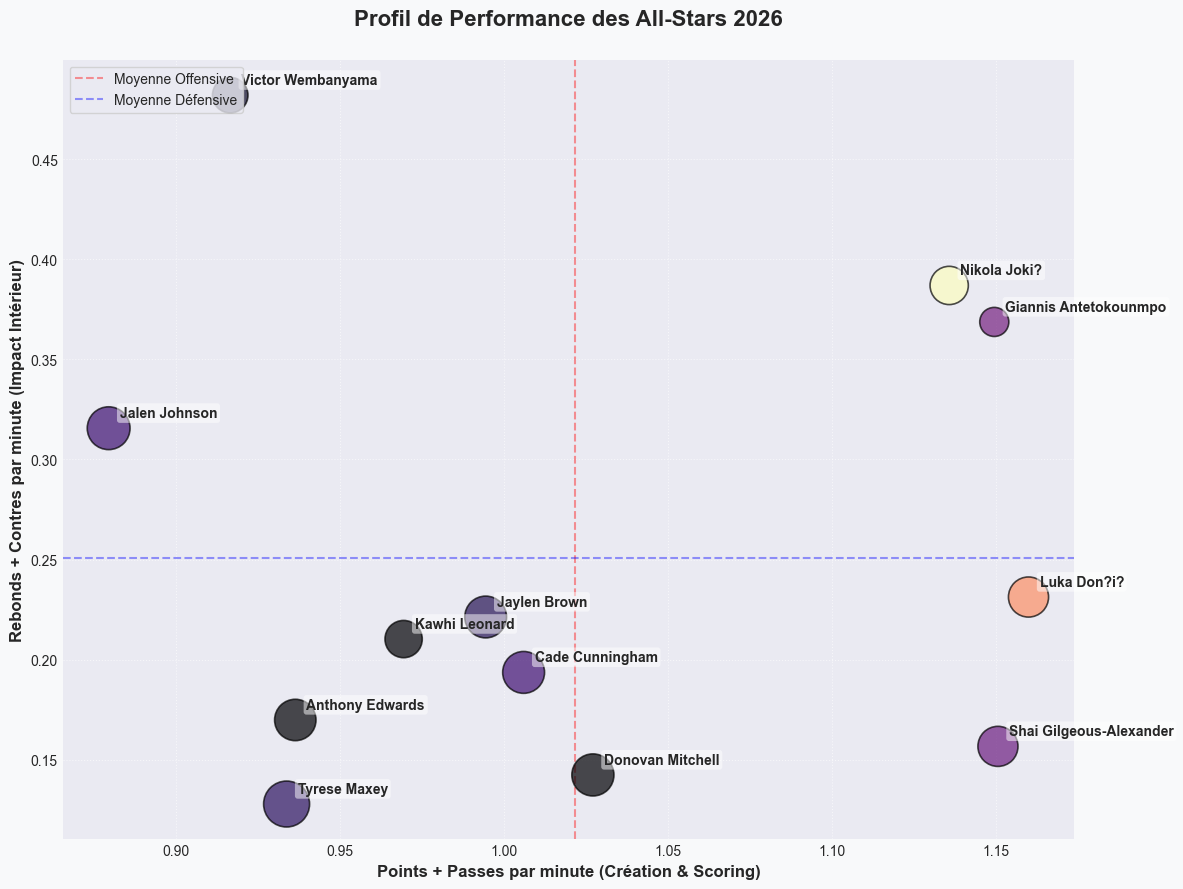

✅ Graphique enregistré sous : images_players/correlation_allstars_x_offensive_y_defensive.png


In [45]:

# 1. Préparation des données All-Star
all_stars_plot = df_2026.nlargest(12, 'composite').copy()
all_stars_plot['mp'] = pd.to_numeric(all_stars_plot['mp'], errors='coerce').fillna(0)

# 2. Calcul des ratios par minute pour les axes demandés
# Axe X : Points + Passes par minute
all_stars_plot['offensive_pm'] = (all_stars_plot['pts'] + all_stars_plot['ast']) / all_stars_plot['mp'].replace(0, 1)
# Axe Y : Rebonds + Contres par minute
all_stars_plot['defensive_pm'] = (all_stars_plot['trb'] + all_stars_plot['blk']) / all_stars_plot['mp'].replace(0, 1)

# 3. Création du graphique
plt.figure(figsize=(12, 9), facecolor='#f8f9fa')
ax = plt.gca()

# Tracé des points
# La couleur dépend du score composite et la taille du temps de jeu (mp)
scatter = plt.scatter(all_stars_plot['offensive_pm'], 
                      all_stars_plot['defensive_pm'], 
                      s=all_stars_plot['mp'] * 0.5, # Taille selon minutes jouées
                      c=all_stars_plot['composite'], 
                      cmap='magma', 
                      alpha=0.7, 
                      edgecolors='black', 
                      linewidth=1.2,
                      zorder=3)

# 4. Ajout des étiquettes (Noms des joueurs)
for i, txt in enumerate(all_stars_plot['player']):
    plt.annotate(txt, 
                 (all_stars_plot['offensive_pm'].iloc[i], all_stars_plot['defensive_pm'].iloc[i]),
                 xytext=(8, 8), 
                 textcoords='offset points', 
                 fontsize=10, 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.5, ec='none'))

# 5. Lignes de moyennes (Quadrants)
plt.axvline(all_stars_plot['offensive_pm'].mean(), color='red', linestyle='--', alpha=0.4, label='Moyenne Offensive')
plt.axhline(all_stars_plot['defensive_pm'].mean(), color='blue', linestyle='--', alpha=0.4, label='Moyenne Défensive')

# 6. Habillage style "Datamb"
plt.title("Profil de Performance des All-Stars 2026", fontsize=16, fontweight='bold', pad=25)
plt.xlabel("Points + Passes par minute (Création & Scoring)", fontsize=12, fontweight='bold')
plt.ylabel("Rebonds + Contres par minute (Impact Intérieur)", fontsize=12, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.legend(loc='upper left', frameon=True)

# Sauvegarde de haute qualité
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "correlation_allstars_x_offensive_y_defensive.png"), bbox_inches='tight', dpi=1080)
plt.show()

print(f"✅ Graphique enregistré sous : {output_dir}/correlation_allstars_x_offensive_y_defensive.png")

# MVP ET défenseur de l'année 2026

In [46]:
# défenseur de l'année 2026
print("\nCalcul du défenseur de l'année 2026 en utilisant la somme des interceptions et contres par match...")
top_defenseur_2026 = df_2026.nlargest(1, 'defense')
print("\n🛡️ Défenseur de l'année 2026 :")
print(top_defenseur_2026[['player', 'defense']].to_string(index=False))

# MVP 2026
print("\nCalcul du MVP 2026 en utilisant le score composite...")
top_mvp_2026 = df_2026.nlargest(1, 'composite')
print("\n🏆 MVP de l'année 2026 :"  )
print(top_mvp_2026[['player', 'composite']].to_string(index=False))


Calcul du défenseur de l'année 2026 en utilisant la somme des interceptions et contres par match...

🛡️ Défenseur de l'année 2026 :
           player  defense
Victor Wembanyama 3.822222

Calcul du MVP 2026 en utilisant le score composite...

🏆 MVP de l'année 2026 :
      player  composite
Nikola Joki?  53.886364


### analyse des playoff

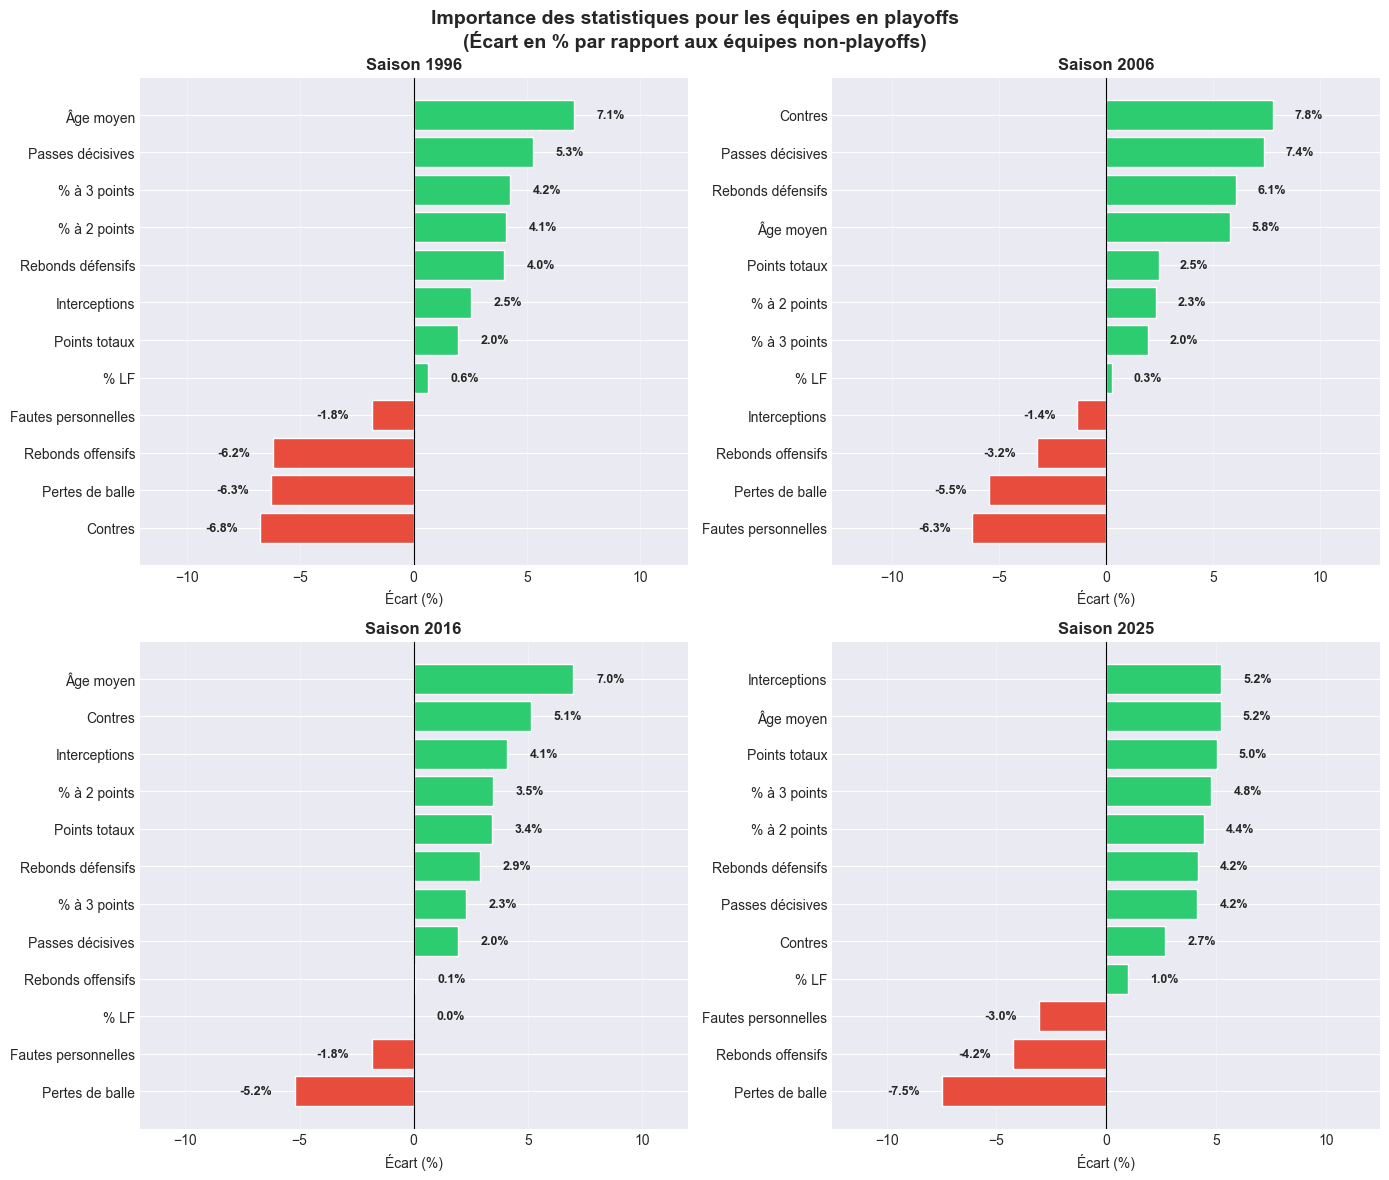

In [47]:
seasons_of_interest = [1996, 2006, 2016, 2025]
df_filtered = df_confer_96

# 3. Créer la colonne 'is_playoff' (déjà présente dans les données)
# Vérifier que la colonne 'playoffs' existe
if 'playoffs' in df_filtered.columns:
    df_filtered['is_playoff'] = df_filtered['playoffs'].astype(bool)
else:
    # Si la colonne n'existe pas, utiliser 'w' pour déterminer les playoffs
    # (les équipes avec un certain nombre de victoires)
    df_filtered['is_playoff'] = df_filtered['w'] >= 37  # Seuil approximatif

# 4. Sélectionner les statistiques à analyser
stats_columns = [
    'pts',           # Points totaux
    'pf',            # Fautes personnelles
    'tov',           # Pertes de balle
    'blk',           # Contres
    'stl',           # Interceptions
    'ast',           # Passes décisives
    'orb',           # Rebonds offensifs
    'drb',           # Rebonds défensifs
    'age',           # Âge moyen
    'x3p_percent',   # Pourcentage à 3-points
    'x2p_percent',   # Pourcentage à 2-points
    'ft_percent'     # Pourcentage de lancers-francs
]

# Vérifier que toutes les colonnes existent
existing_stats = [col for col in stats_columns if col in df_filtered.columns]
missing_stats = [col for col in stats_columns if col not in df_filtered.columns]
if missing_stats:
    print(f"Colonnes manquantes : {missing_stats}")

# 5. Calculer les moyennes par saison pour les équipes en playoffs
playoff_stats = df_filtered[df_filtered['is_playoff']].groupby('season')[existing_stats].mean()
non_playoff_stats = df_filtered[~df_filtered['is_playoff']].groupby('season')[existing_stats].mean()

# 6. Calculer le ratio d'importance (playoff / non-playoff)
importance_matrix = (playoff_stats / non_playoff_stats - 1) * 100

# 7. Créer la matrice de scores pour la visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Importance des statistiques pour les équipes en playoffs\n(Écart en % par rapport aux équipes non-playoffs)', 
             fontsize=14, fontweight='bold')

# Noms français des statistiques
stat_names_fr = {
    'pts': 'Points totaux',
    'pf': 'Fautes personnelles',
    'tov': 'Pertes de balle',
    'blk': 'Contres',
    'stl': 'Interceptions',
    'ast': 'Passes décisives',
    'orb': 'Rebonds offensifs',
    'drb': 'Rebonds défensifs',
    'age': 'Âge moyen',
    'x3p_percent': '% à 3 points',
    'x2p_percent': '% à 2 points',
    'ft_percent': '% LF'
}

# Palette de couleurs
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in importance_matrix.values.flatten()]

for i, (ax, season) in enumerate(zip(axes.flat, seasons_of_interest)):
    if season in importance_matrix.index:
        data = importance_matrix.loc[season].sort_values()
        
        # Créer les labels en français
        labels = [stat_names_fr.get(idx, idx) for idx in data.index]
        
        # Créer les couleurs (vert si positif, rouge si négatif)
        bar_colors = ['#2ecc71' if val > 0 else '#e74c3c' for val in data.values]
        
        # Barres horizontales
        bars = ax.barh(labels, data.values, color=bar_colors, edgecolor='white', linewidth=1)
        
        # Ajouter les valeurs sur les barres
        for bar, val in zip(bars, data.values):
            ax.text(val + (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2, 
                   f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', 
                   fontsize=9, fontweight='bold')
        
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.set_title(f'Saison {season}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Écart (%)')
        ax.grid(True, alpha=0.3, axis='x')
        
        # Ajuster les limites
        max_val = max(abs(data.values)) + 5
        ax.set_xlim(-max_val, max_val)

plt.tight_layout()
plt.savefig(os.path.join(NBA_Analysis, "Import_stat_péquipes_playoffs.jpg"), dpi=1080, bbox_inches='tight')
plt.show()

# PRÉDICTIONS - MODÈLE DE RÉGRESSION LOGISTIQUE


PRÉDICTIONS - MODÈLE DE RÉGRESSION LOGISTIQUE

🏀 Top 10 - 2026
                 team  season     score  win_pct     elo_end  champion_prob  season_pred
      Detroit Pistons    2026  2.862772 0.758621 1663.626447       0.666333         2026
Oklahoma City Thunder    2026  2.386533 0.754098 1780.144908       0.198333         2026
    San Antonio Spurs    2026  1.900033 0.728814 1809.798196       0.134667         2026
       Boston Celtics    2026 -0.288283 0.661017 1690.116324       0.000333         2026
      Houston Rockets    2026 -0.077181 0.627119 1556.406988       0.000333         2026
        Chicago Bulls    2026 -5.534037 0.400000 1345.695081       0.000000         2026
  Cleveland Cavaliers    2026  0.122608 0.606557 1634.562125       0.000000         2026
    Charlotte Hornets    2026 -4.594437 0.491803 1655.041067       0.000000         2026
       Denver Nuggets    2026 -0.579280 0.616667 1616.489461       0.000000         2026
     Dallas Mavericks    2026 -5.079168 0.3559

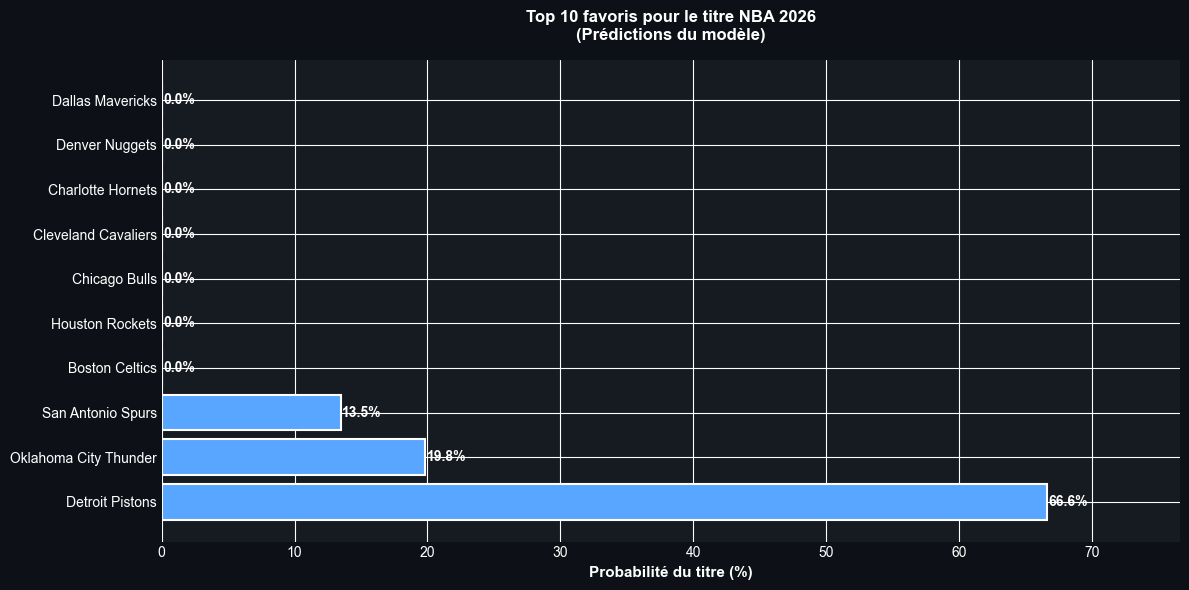

✅ Sauvegardé : champions_histogram_2026.png


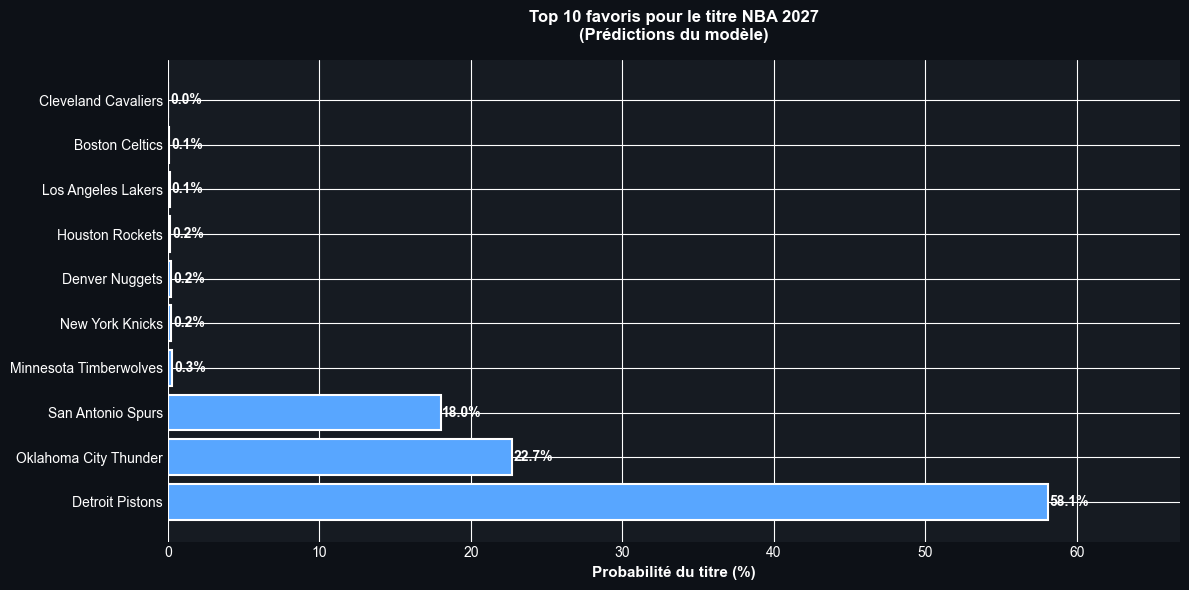

✅ Sauvegardé : champions_histogram_2027.png


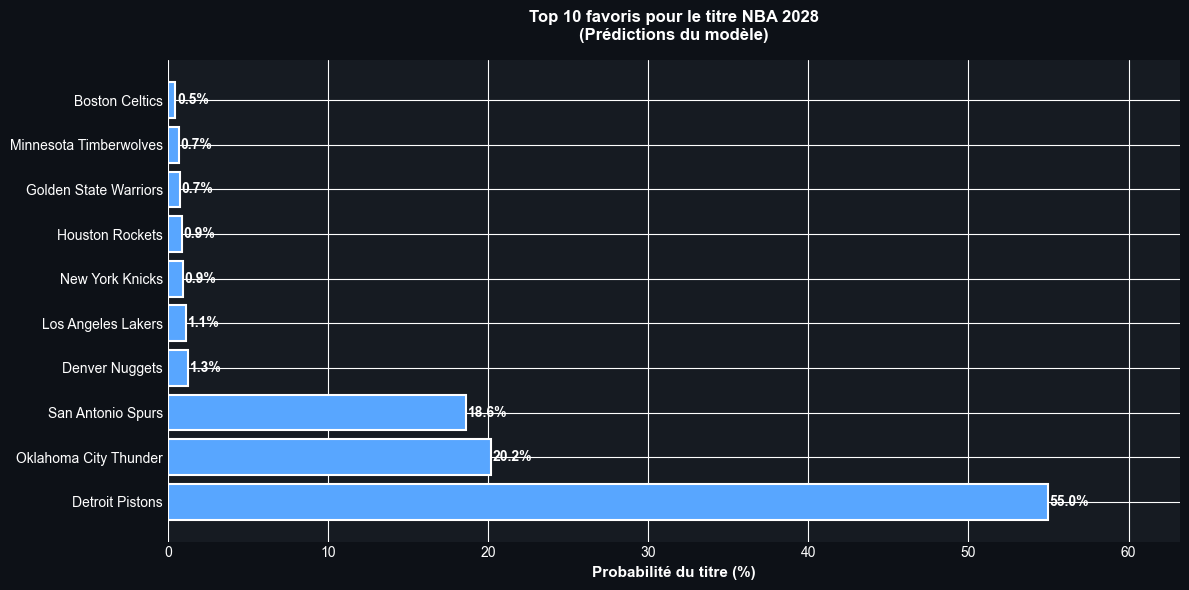

✅ Sauvegardé : champions_histogram_2028.png


In [51]:
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.special import expit



def read_csv_smart(path: str) -> pd.DataFrame:
    attempts = [
        dict(encoding="utf-8", sep=None, engine="python"),
        dict(encoding="latin1", sep=None, engine="python"),
        dict(encoding="cp1252", sep=None, engine="python"),
        dict(encoding="utf-8", sep=";", engine="python"),
        dict(encoding="latin1", sep=";", engine="python"),
        dict(encoding="cp1252", sep=";", engine="python"),
        dict(encoding="utf-8", sep=","),
        dict(encoding="latin1", sep=","),
    ]
    last_err = None
    for kw in attempts:
        try:
            return pd.read_csv(path, **kw)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Impossible de lire {path}") from last_err


def load_data():
    teams = read_csv_smart("Team_Complete.csv")  
    players = read_csv_smart("Player Totals.csv")               
    games = read_csv_smart("Games.csv")  

    for df in (teams, players, games):
        df.columns = [c.strip() for c in df.columns]

    teams = teams[teams["team"].ne("League Average")].copy()
    teams["season"] = teams["season"].astype(int)
    players["season"] = players["season"].astype(int)

    games["gameDateTimeEst"] = pd.to_datetime(games["gameDateTimeEst"], dayfirst=True, errors="coerce")
    games["season"] = np.where(
        games["gameDateTimeEst"].dt.month >= 7,
        games["gameDateTimeEst"].dt.year + 1,
        games["gameDateTimeEst"].dt.year,
    ).astype(int)
    games["home_team"] = games["hometeamCity"].astype(str).str.strip() + " " + games["hometeamName"].astype(str).str.strip()
    games["away_team"] = games["awayteamCity"].astype(str).str.strip() + " " + games["awayteamName"].astype(str).str.strip()

    reg_games = games[(games["gameType"] == "Regular Season") & games["homeScore"].gt(0) & games["awayScore"].gt(0)].copy()
    return teams, players, reg_games


def build_elo(reg_games: pd.DataFrame, home_adv: float = 65.0, k: float = 20.0, season_regr: float = 0.75):
    def expected(r_a, r_b):
        return 1.0 / (1.0 + 10 ** ((r_b - r_a) / 400))

    def mov_multiplier(mov, rd):
        return math.log(abs(mov) + 1.0) * (2.2 / ((abs(rd) * 0.001) + 2.2))

    ratings = {}
    season_end = {}
    prev_season = None

    for season, g in reg_games.sort_values("gameDateTimeEst").groupby("season", sort=True):
        if prev_season is not None:
            for team in list(ratings.keys()):
                ratings[team] = season_regr * ratings[team] + (1 - season_regr) * 1500.0
        prev_season = season

        for _, row in g.iterrows():
            home = row["home_team"]
            away = row["away_team"]
            hs = float(row["homeScore"])
            aas = float(row["awayScore"])

            ratings.setdefault(home, 1500.0)
            ratings.setdefault(away, 1500.0)

            r_home = ratings[home]
            r_away = ratings[away]

            p_home = expected(r_home + home_adv, r_away)
            home_win = 1.0 if hs > aas else 0.0
            delta = k * mov_multiplier(hs - aas, r_home - r_away) * (home_win - p_home)

            ratings[home] = r_home + delta
            ratings[away] = r_away - delta

        season_end[season] = ratings.copy()

    elo_rows = [
        {"season": season, "team": team, "elo_end": rating}
        for season, season_map in season_end.items()
        for team, rating in season_map.items()
    ]
    return pd.DataFrame(elo_rows)


def build_player_aggregates(players: pd.DataFrame):
    players_clean = players[~players["team"].isin(["2TM", "3TM", "4TM", "5TM"])].copy()
    for c in ["mp", "pts", "ast", "trb", "stl", "blk", "tov", "pf", "fg", "fga", "x3p", "x3pa", "x2p", "x2pa", "ft", "fta", "orb", "drb", "gs", "g", "age"]:
        players_clean[c] = pd.to_numeric(players_clean[c], errors="coerce")

    def weighted_age(g):
        mp = g["mp"].fillna(0)
        age = g["age"].fillna(g["age"].mean())
        s = mp.sum()
        return float(np.average(age, weights=mp)) if s > 0 else np.nan

    base = players_clean.groupby(["season", "team"]).agg(
        players=("player_id", "count"),
        total_mp=("mp", "sum"),
        total_pts=("pts", "sum"),
        total_ast=("ast", "sum"),
        total_trb=("trb", "sum"),
        total_stl=("stl", "sum"),
        total_blk=("blk", "sum"),
        total_tov=("tov", "sum"),
        avg_age=("age", "mean"),
    ).reset_index()
    base["wavg_age"] = players_clean.groupby(["season", "team"]).apply(weighted_age, include_groups=False).values

    def topk_summary(g):
        out = {}
        for col, ks in [("pts", [1, 3, 5]), ("mp", [1, 3, 5])]:
            vals = pd.to_numeric(g[col], errors="coerce").fillna(0).sort_values(ascending=False)
            total = vals.sum()
            for k in ks:
                out[f"top{k}_{col}"] = vals.head(k).sum()
            out[f"{col}_share_top3"] = vals.head(3).sum() / total if total > 0 else np.nan
        out["rotation_players_500mp"] = int((pd.to_numeric(g["mp"], errors="coerce").fillna(0) >= 500).sum())
        out["rotation_players_1000mp"] = int((pd.to_numeric(g["mp"], errors="coerce").fillna(0) >= 1000).sum())
        return pd.Series(out)

    top = players_clean.groupby(["season", "team"]).apply(topk_summary, include_groups=False).reset_index()
    return base.merge(top, on=["season", "team"], how="left")


def build_model_table(teams: pd.DataFrame, elo_df: pd.DataFrame, player_agg: pd.DataFrame):
    df = teams.copy()
    df["win_pct"] = df["w"] / (df["w"] + df["l"])
    for c in ["pts", "trb", "ast", "tov", "fg", "fga", "x3p", "x3pa", "ft", "fta", "orb", "drb", "stl", "blk"]:
        df[f"{c}_pg"] = df[c] / df["g"]

    df = df.merge(elo_df, on=["season", "team"], how="left")
    df = df.merge(player_agg, left_on=["season", "abbreviation_x"], right_on=["season", "team"], how="left", suffixes=("", "_player"))

    for c in ["total_mp", "total_pts", "total_ast", "total_trb", "total_stl", "total_blk", "total_tov",
              "top1_pts", "top3_pts", "top5_pts", "top1_mp", "top3_mp", "top5_mp"]:
        df[f"{c}_pg"] = df[c] / df["g"]

    df["pts_per_player"] = df["total_pts"] / df["players"]
    df["mp_per_player"] = df["total_mp"] / df["players"]
    return df


def train_champion_model(model_df: pd.DataFrame):
    feature_cols = [
        "win_pct", "g", "elo_end",
        "pts_pg", "trb_pg", "ast_pg", "tov_pg", "fg_percent", "x3p_percent", "ft_percent",
        "orb_pg", "drb_pg", "stl_pg", "blk_pg",
        "players", "avg_age", "wavg_age",
        "total_pts_pg", "total_ast_pg", "total_trb_pg", "total_tov_pg",
        "top1_pts_pg", "top3_pts_pg", "top5_pts_pg", "pts_share_top3",
        "top1_mp_pg", "top3_mp_pg", "top5_mp_pg", "mp_share_top3",
        "rotation_players_500mp", "rotation_players_1000mp",
        "pts_per_player", "mp_per_player",
    ]

    train_df = model_df[(model_df["season"] <= 2025) & model_df["is_champion"].notna()].copy()
    train_df["target"] = train_df["is_champion"].astype(int)

    clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=0.7, solver="liblinear")),
    ])
    clf.fit(train_df[feature_cols], train_df["target"])
    return clf, feature_cols


def project_season(df: pd.DataFrame, feature_cols: list[str], model_df: pd.DataFrame, years_ahead: int = 1):
    proj = df.copy()
    hist_means = model_df[feature_cols].mean(numeric_only=True)
    carry = 0.78 ** years_ahead

    for col in feature_cols:
        if col == "g":
            proj[col] = 82.0
        elif col in ["avg_age", "wavg_age"]:
            proj[col] = pd.to_numeric(proj[col], errors="coerce") + years_ahead
        elif col == "win_pct":
            proj[col] = carry * pd.to_numeric(proj[col], errors="coerce") + (1 - carry) * 0.50
        elif col == "elo_end":
            proj[col] = carry * pd.to_numeric(proj[col], errors="coerce") + (1 - carry) * 1500.0
        else:
            proj[col] = carry * pd.to_numeric(proj[col], errors="coerce") + (1 - carry) * hist_means[col]
    return proj


def simulate_bracket(df: pd.DataFrame, top_n: int = 16, n_sim: int = 3000, seed: int = 7):
    score_map = df.set_index("team")["score"].to_dict()
    teams_sorted = df.sort_values("score", ascending=False).head(top_n)["team"].tolist()
    counts = {t: 0 for t in teams_sorted}

    def series_winner(a, b):
        p = expit(score_map[a] - score_map[b])
        wa = wb = 0
        while wa < 4 and wb < 4:
            if np.random.rand() < p:
                wa += 1
            else:
                wb += 1
        return a if wa > wb else b

    for i in range(n_sim):
        np.random.seed(seed + i)
        bracket = teams_sorted.copy()
        while len(bracket) > 1:
            nxt = []
            for j in range(0, len(bracket), 2):
                nxt.append(series_winner(bracket[j], bracket[j + 1]))
            bracket = nxt
        counts[bracket[0]] += 1

    return pd.DataFrame({"team": list(counts.keys()), "champion_prob": [v / n_sim for v in counts.values()]})


def predict_year(df, clf, feature_cols, model_df, years_ahead: int = 0, n_sim: int = 3000):
    if years_ahead > 0:
        df = project_season(df, feature_cols, model_df, years_ahead=years_ahead)

    df = df.copy()
    df["score"] = clf.decision_function(df[feature_cols])
    probs = simulate_bracket(df, top_n=16, n_sim=n_sim)
    out = df[["team", "season", "score", "win_pct", "elo_end"]].merge(probs, on="team", how="left").fillna({"champion_prob": 0})
    return out.sort_values("champion_prob", ascending=False)


def plot_predictions_histogram(pred_df, year, top_n=10):
    """Crée un histogramme des probabilités de champion avec pourcentages"""
    top_teams = pred_df.head(top_n).copy()
    top_teams["champion_prob_pct"] = top_teams["champion_prob"] * 100
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    
    bars = ax.barh(top_teams["team"], top_teams["champion_prob_pct"], 
                    color='#58a6ff', edgecolor='white', linewidth=1.5)
    
    # Ajouter les pourcentages sur les barres
    for i, (bar, pct) in enumerate(zip(bars, top_teams["champion_prob_pct"])):
        ax.text(pct + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center', color='white', fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Probabilité du titre (%)', color='white', fontsize=11, fontweight='bold')
    ax.set_title(f'Top {top_n} favoris pour le titre NBA {year}\n(Prédictions du modèle)', 
                 color='white', fontsize=12, fontweight='bold', pad=15)
    ax.tick_params(colors='white', labelsize=10)
    ax.set_xlim(0, max(top_teams["champion_prob_pct"]) * 1.15)
    
    for spine in ax.spines.values():
        spine.set_color('#30363d')
    
    plt.tight_layout()
    plt.savefig(f'champions_histogram_{year}.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"✅ Sauvegardé : champions_histogram_{year}.png")


def main():
    teams, players, reg_games = load_data()
    elo_df = build_elo(reg_games)
    player_agg = build_player_aggregates(players)
    model_df = build_model_table(teams, elo_df, player_agg)
    clf, feature_cols = train_champion_model(model_df)

    current_2026 = model_df[model_df["season"] == 2026].copy()

    pred_2026 = predict_year(current_2026, clf, feature_cols, model_df, years_ahead=0, n_sim=3000)
    pred_2027 = predict_year(current_2026, clf, feature_cols, model_df, years_ahead=1, n_sim=3000)
    pred_2028 = predict_year(current_2026, clf, feature_cols, model_df, years_ahead=2, n_sim=3000)

    pred_2026["season_pred"] = 2026
    pred_2027["season_pred"] = 2027
    pred_2028["season_pred"] = 2028

    all_preds = pd.concat([pred_2026, pred_2027, pred_2028], ignore_index=True)
    all_preds.to_csv("predictions_2026_2028.csv", index=False)

    print("\n" + "="*60)
    print("PRÉDICTIONS - MODÈLE DE RÉGRESSION LOGISTIQUE")
    print("="*60)
    
    print("\n🏀 Top 10 - 2026")
    print(pred_2026.head(10).to_string(index=False))
    print("\n🏀 Top 10 - 2027")
    print(pred_2027.head(10).to_string(index=False))
    print("\n🏀 Top 10 - 2028")
    print(pred_2028.head(10).to_string(index=False))
    
    # Créer les histogrammes avec pourcentages
    print("\n📊 Création des histogrammes...")
    plot_predictions_histogram(pred_2026, 2026, top_n=10)
    plot_predictions_histogram(pred_2027, 2027, top_n=10)
    plot_predictions_histogram(pred_2028, 2028, top_n=10)


if __name__ == "__main__":
    main()